# Jan Brzozowski, Jędrzej Dubiak

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('data_num2.csv')

## Wstępna analiza danych

Analizę zaczniemy od skrócenia nazw kolumn, by ułatwić operowanie na danych.

In [2]:
short_column_names = {
    'GNI per capita. PPP (current international $)': 'GNI_per_capita',
    'Inflation. consumer prices (annual %)': 'Inflation',
    'GDP (current US$)': 'GDP_USD',
    'GDP growth (annual %)': 'GDP_growth',
    'Unemployment. total (% of total labor force) (modeled ILO estimate)': 'Unemployment_rate',
    'Central government debt. total (% of GDP)': 'Govt_debt_GDP',
    'Population density (people per sq. km of land area)': 'Pop_density',
    'Population. total': 'Population_total',
    'Population ages 0-14 (% of total population)': 'Pop_0_14',
    'Urban population (% of total population)': 'Urban_pop',
    'Population ages 15-64. total': 'Pop_15_64',
    'Population ages 65 and above (% of total population)': 'Pop_65_plus',
    'Life expectancy at birth. total (years)': 'Life_expectancy',
    'Current health expenditure (% of GDP)': 'Health_exp_GDP',
    'Current health expenditure per capita (current US$)': 'Health_exp_per_capita',
    'Railways. passengers carried (million passenger-km)': 'Rail_passengers',
    'Air transport. passengers carried': 'Air_passengers',
    'Control of Corruption: Estimate': 'Corruption_control',
    'Government Effectiveness: Estimate': 'Govt_effectiveness',
    'Political Stability and Absence of Violence/Terrorism: Estimate': 'Political_stability',
    'Regulatory Quality: Estimate': 'Regulatory_quality',
    'Rule of Law: Estimate': 'Rule_of_law',
    'Voice and Accountability: Estimate': 'Voice_accountability',
    'International tourism. number of arrivals': 'Tourism_arrivals',
    'International tourism. number of departures': 'Tourism_departures',
    'Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e)': 'CO2_transport',
    'Land area (sq. km)': 'Land_area',
    'Nitrous oxide (N2O) emissions from Transport (Energy) (Mt CO2e)': 'N2O_transport',
    'Country Name': 'Country',
    'Fatalities': 'Fatalities'
}

data.rename(columns=short_column_names, inplace=True)

### Opisy atrybutów

##### GNI per capita, PPP (current international $)
Ten wskaźnik informuje o  wartości dochodu narodowego brutto (GNI, wcześniej GNP) na osobę, wyrażone w bieżących międzynarodowych dolarach przeliczonych za pomocą współczynnika parytetu siły nabywczej (PPP). GNI to suma wartości dodanej przez wszystkich krajowych producentów oraz podatków od produktów (pomniejszona o dotacje) nieuwzględnionych w wycenie produkcji, a także dochodów pierwotnych (wynagrodzenia pracowników i dochody z własności) uzyskanych z zagranicy. Współczynnik PPP jest przestrzennym deflatorem cen i przelicznikiem walutowym, który eliminuje różnice w poziomach cen między krajami.

##### Inflation, consumer prices (annual %)
Inflacja, mierzona wskaźnikiem cen towarów i usług konsumpcyjnych, odzwierciedla roczną procentową zmianę kosztów ponoszonych przez przeciętnego konsumenta na zakup koszyka dóbr i usług, który może być stały lub zmieniany w określonych odstępach czasu, na przykład rocznie.

##### GDP (current US$)
PKB w cenach nabywcy to suma wartości dodanej brutto wszystkich krajowych producentów w gospodarce oraz podatków od produktów pomniejszonych o dotacje nieuwzględnione w wartości produktów. Obliczenia te nie uwzględniają odpisów amortyzacyjnych ani zużycia i degradacji zasobów naturalnych. Dane są wyrażone w bieżących dolarach amerykańskich. Wartości PKB są przeliczane z walut krajowych za pomocą oficjalnych kursów wymiany obowiązujących w danym roku.

##### GDP growth (annual %)
Roczna procentowa stopa wzrostu PKB w cenach rynkowych, wyrażona w stałych walutach lokalnych. PKB to suma wartości dodanej brutto wszystkich krajowych producentów oraz podatków od produktów pomniejszonych o dotacje nieuwzględnione w wartości produktów. Nie uwzględnia się odpisów amortyzacyjnych ani zużycia i degradacji zasobów naturalnych.

##### Unemployment, total (% of total labor force) (modeled ILO estimate)
Bezrobocie odnosi się do odsetka siły roboczej, która pozostaje bez pracy, ale jest dostępna i aktywnie jej poszukuje.

##### Central government debt, total (% of GDP)
Dług publiczny obejmuje całkowitą wartość zobowiązań rządu o określonym terminie zapadalności wobec innych podmiotów. Obejmuje on zarówno zobowiązania krajowe, jak i zagraniczne, takie jak waluty i depozyty pieniężne, papiery wartościowe inne niż akcje oraz pożyczki. Jest to wartość brutto zobowiązań rządowych pomniejszona o wartość udziałów kapitałowych i instrumentów pochodnych posiadanych przez rząd. Ponieważ dług jest stanem, a nie przepływem, jest mierzony na określony dzień, zwykle ostatni dzień roku budżetowego.

##### Population density (people per sq. km of land area)
Gęstość zaludnienia to liczba ludności w połowie roku podzielona przez powierzchnię kraju w kilometrach kwadratowych. Ludność opiera się na definicji de facto, obejmującej wszystkich mieszkańców, niezależnie od statusu prawnego czy obywatelstwa, z wyjątkiem uchodźców, którzy nie osiedlili się na stałe w kraju azylu, a którzy są zwykle traktowani jako część populacji kraju pochodzenia. Powierzchnia kraju obejmuje obszary lądowe z wyłączeniem wód śródlądowych, stref wyłączności ekonomicznej i roszczeń do szelfu kontynentalnego.

##### Population, total
Całkowita populacja opiera się na definicji de facto, obejmującej wszystkich mieszkańców, niezależnie od statusu prawnego czy obywatelstwa. Podane wartości to szacunki z połowy roku.

##### Population ages 0-14 (% of total population)
Populacja w wieku od 0 do 14 lat jako procent całkowitej populacji.

##### Urban population (% of total population)
Ludność miejska odnosi się do osób zamieszkujących obszary miejskie, zdefiniowane przez krajowe urzędy statystyczne. Dane są zbierane i wygładzane przez Wydział Ludności Narodów Zjednoczonych.

##### Population ages 15-64, total
Całkowita populacja w wieku od 15 do 64 lat.

##### Population ages 65 and above (% of total population)
Populacja w wieku 65 lat i więcej jako procent całkowitej populacji.

##### Life expectancy at birth, total (years)
Oczekiwana długość życia przy urodzeniu wskazuje liczbę lat, które noworodek przeżyje, jeśli obecne wzorce umieralności w momencie jego urodzenia utrzymają się przez całe jego życie.

##### Current health expenditure (% of GDP)
Poziom bieżących wydatków na ochronę zdrowia wyrażony jako procent PKB. Szacunki obejmują dobra i usługi zdrowotne konsumowane w danym roku. Nie obejmują wydatków kapitałowych, takich jak budynki, maszyny, technologie informacyjne i zapasy szczepionek na wypadek sytuacji kryzysowych lub epidemii.

##### Current health expenditure per capita (current US$)
Bieżące wydatki na ochronę zdrowia na osobę, wyrażone w bieżących dolarach amerykańskich. Szacunki obejmują dobra i usługi zdrowotne konsumowane w danym roku.

##### Railways, passengers carried (million passenger-km)
Liczba pasażerów przewiezionych koleją to liczba osób transportowanych koleją pomnożona przez przebyty dystans w kilometrach.

##### Air transport, passengers carried
Pasażerowie przewiezieni transportem lotniczym obejmują pasażerów lotów krajowych i międzynarodowych obsługiwanych przez przewoźników lotniczych zarejestrowanych w danym kraju.

##### International tourism, number of arrivals
Międzynarodowi turyści przyjeżdżający (nocujący) to liczba osób podróżujących do kraju innego niż kraj ich stałego zamieszkania, ale poza ich zwyczajowym środowiskiem, na okres nieprzekraczający 12 miesięcy, których głównym celem wizyty nie jest działalność wynagradzana w odwiedzanym kraju. W przypadku braku danych o liczbie turystów podawana jest liczba odwiedzających, która obejmuje turystów, jednodniowych gości, pasażerów rejsów i członków załogi.

##### International tourism, number of departures
Międzynarodowi turyści wyjeżdżający to liczba wyjazdów osób opuszczających swój kraj zamieszkania do innego kraju w celach innych niż działalność wynagradzana w kraju odwiedzanym. Dane odnoszą się do liczby wyjazdów, a nie osób podróżujących.

##### Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e)
Miara rocznej emisji dwutlenku węgla (CO2), jednego z sześciu gazów cieplarnianych według protokołu z Kioto, z sektora transportowego (podsektor sektora energetycznego). Emisje są standaryzowane do ekwiwalentów CO2 z wykorzystaniem współczynników Global Warming Potential (GWP) z Piątego Raportu Oceny IPCC (AR5).

##### Land area (sq. km)
Powierzchnia lądowa to całkowity obszar kraju z wyłączeniem wód śródlądowych, roszczeń do szelfu kontynentalnego i stref wyłączności ekonomicznej.

##### Nitrous oxide (N2O) emissions from Transport (Energy) (Mt CO2e)
Miara rocznej emisji podtlenku azotu (N2O), jednego z sześciu gazów cieplarnianych według protokołu z Kioto, z sektora transportowego. Emisje są standaryzowane do ekwiwalentów CO2 z wykorzystaniem współczynników GWP z Piątego Raportu Oceny IPCC (AR5).

#### Wskaźniki Worldwide Governance Indicators
Wskaźniki Worldwide Governance Indicators (WGI) to zestaw danych badawczych podsumowujących opinie na temat jakości zarządzania, wyrażane przez szeroką grupę respondentów – przedsiębiorców, obywateli i ekspertów – w krajach rozwiniętych i rozwijających się. Dane te są zbierane przez liczne instytuty badawcze, think tanki, organizacje pozarządowe, organizacje międzynarodowe oraz firmy z sektora prywatnego. 

##### Control of Corruption: Estimate
Ocenia, w jakim stopniu władze kontrolują korupcję, w tym korupcję polityczną i administracyjną.

##### Government Effectiveness: Estimate
Mierzy jakość usług publicznych, kompetencje urzędników oraz niezależność administracji od presji politycznej.

##### Political Stability and Absence of Violence/Terrorism: Estimate
Ocenia prawdopodobieństwo wystąpienia niestabilności politycznej, przemocy lub terroryzmu.

##### Regulatory Quality: Estimate
Ocenia zdolność rządu do formułowania i wdrażania polityk sprzyjających rozwojowi sektora prywatnego.

##### Rule of Law: Estimate
Wskazuje na stopień przestrzegania prawa, w tym skuteczność sądów i ochrona praw własności.

##### Voice and Accountability: Estimate
Mierzy poziom wolności obywatelskich, udział obywateli w rządzeniu oraz wolność mediów.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   775 non-null    int64  
 1   GNI_per_capita         750 non-null    float64
 2   Inflation              750 non-null    float64
 3   GDP_USD                774 non-null    float64
 4   GDP_growth             761 non-null    float64
 5   Unemployment_rate      750 non-null    float64
 6   Govt_debt_GDP          720 non-null    float64
 7   Pop_density            711 non-null    float64
 8   Population_total       775 non-null    int64  
 9   Pop_0_14               775 non-null    float64
 10  Urban_pop              775 non-null    float64
 11  Pop_15_64              775 non-null    int64  
 12  Pop_65_plus            775 non-null    float64
 13  Life_expectancy        744 non-null    float64
 14  Health_exp_GDP         674 non-null    float64
 15  Health

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,775.0,2.011000e+03,7.215759e+00,1.999000e+03,2.005000e+03,2.011000e+03,2.017000e+03,2.023000e+03
GNI_per_capita,750.0,3.665903e+04,1.788763e+04,5.530000e+03,2.486250e+04,3.378500e+04,4.594750e+04,1.280200e+05
Inflation,750.0,3.045639e+00,3.960048e+00,-4.447547e+00,1.104922e+00,2.273203e+00,3.544140e+00,4.580378e+01
GDP_USD,774.0,5.548644e+11,8.648900e+11,2.483890e+09,4.970054e+10,2.171740e+11,5.241130e+11,4.456080e+12
GDP_growth,761.0,2.347263e+00,3.650985e+00,-1.483861e+01,9.414709e-01,2.461473e+00,4.179949e+00,2.447525e+01
Unemployment_rate,750.0,7.922012e+00,4.271521e+00,1.805000e+00,4.890250e+00,6.927000e+00,9.688750e+00,2.768600e+01
Govt_debt_GDP,720.0,6.706455e+01,4.235046e+01,3.811326e+00,3.606781e+01,5.640267e+01,9.105163e+01,2.532259e+02
Pop_density,711.0,1.285457e+02,1.041442e+02,2.766893e+00,6.597753e+01,1.081138e+02,1.766827e+02,5.207319e+02
Population_total,775.0,1.665982e+07,2.207044e+07,3.261500e+04,3.349802e+06,8.009142e+06,1.630082e+07,8.448227e+07
Pop_0_14,775.0,1.636369e+01,2.027781e+00,1.219839e+01,1.478621e+01,1.596181e+01,1.765893e+01,2.340109e+01


Widzimy, że wszystkie atrybuty, oprócz "Country", są atrybutami ilościowymi. Atrybutu "Country" nie będziemy wykorzystywac do zadania regresji, ale na razie zostanie on w naszym zbiorze by ułatwić nam pracę z danymi.

### Analiza stopnia wypełnienia danych

Funkcja obliczająca ilość brakujących wartości w danej kolumnie oraz ich procentowy udział.

In [5]:
def get_values_statistics(df):
	missing_values = df.isnull().sum().reset_index()
	missing_values.columns = ['Column', 'Missing Values']
	missing_values['Percentage'] = (missing_values['Missing Values'] / len(df)) * 100

	missing_values = missing_values.sort_values(by='Missing Values', ascending=False)
	missing_values = missing_values.reset_index(drop=True)
	return missing_values

In [6]:
missing_values = get_values_statistics(data)
missing_values

,Column,Missing Values,Percentage
0,Tourism_departures,231,29.806452
1,Tourism_arrivals,141,18.193548
2,Rail_passengers,138,17.806452
3,Air_passengers,128,16.516129
4,Health_exp_per_capita,101,13.032258
5,Health_exp_GDP,101,13.032258
6,Pop_density,64,8.258065
7,Voice_accountability,62,8.000000
8,Rule_of_law,62,8.000000
9,Regulatory_quality,62,8.000000


Pierwszym rzucającym się w oczy problemem, który możemy naprawić jest kolumna "Pop_density", zawierająca informacje o gęstości zaludnienia. W tej kolumnie brakuje 8.258065% danych. Dane możemy uzupełnić po prostu obliczając ten wskaźnik, korzystając z powierrzchni danego kraju i jego populacji.

In [7]:
data["Pop_density"] = data["Population_total"] / data["Land_area"]
missing_values = get_values_statistics(data)
missing_values

,Column,Missing Values,Percentage
0,Tourism_departures,231,29.806452
1,Tourism_arrivals,141,18.193548
2,Rail_passengers,138,17.806452
3,Air_passengers,128,16.516129
4,Health_exp_per_capita,101,13.032258
5,Health_exp_GDP,101,13.032258
6,Voice_accountability,62,8.000000
7,Rule_of_law,62,8.000000
8,Regulatory_quality,62,8.000000
9,Political_stability,62,8.000000


Postanowiliśmy usunąć kolumny, w których udział brakujących danych jest powyżej 10%

In [8]:
for i in range(missing_values.shape[0]):
	if missing_values.iloc[i,:]["Percentage"] > 10:
		data= data.drop([missing_values.iloc[i,:]["Column"]], axis=1)

In [9]:
print("Liczba atrybutów = ", data.shape[1])
print("Początkowa liczba obiektów = ", data.shape[0])


for col in data.columns:
	if col != "Country":
		medians = data.groupby('Country')[col].transform('median')
		data[col] = data[col].fillna(medians)

data = data.dropna(how="any")
print("Liczba obiektów po usunięciu = ", data.shape[0])

Liczba atrybutów =  25
Początkowa liczba obiektów =  775
Liczba obiektów po usunięciu =  725


### Sprawdzenie zależności z wizualizacjami

In [10]:
def plot_corr_matrix():
	data_no_country = data.drop(columns=['Country'])
	correlation_matrix = data_no_country.corr()

	plt.figure(figsize=(15, 12))
	sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
	plt.title("Macierz korelacji")
	plt.show()

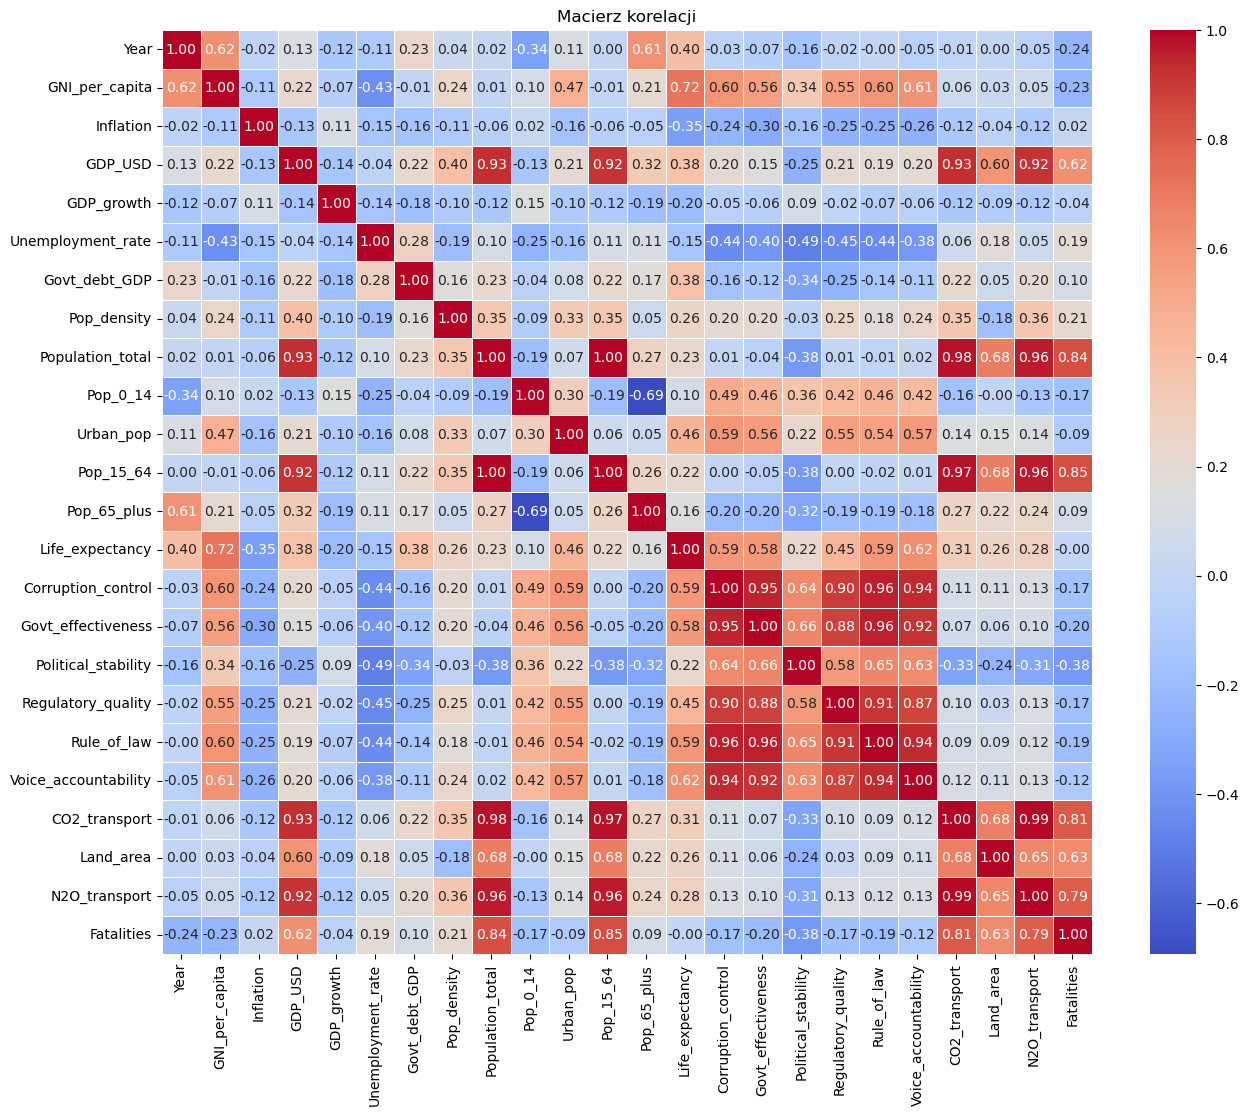

In [11]:
plot_corr_matrix()

Część danych musi zostać odpowiednio przeskalowana. Dobrym przykładem może być kolumna Pop_15_64, gdzie podana jest ilość obywateli od 15 do 64 roku życia. Znacznie bardziej przydatną cechą byłby procentowy udział tej części społeczeństwa, tak jak w przypadku Pop_0_14 i Pop_65_plus. Pozostałe atrybuty, które zostaną podzielone przez liczbę ludności to PKB i ilość wygenerowanego CO2 i N2O w transporcie.

In [12]:
def scale_by_population(df, column_name):
	df[column_name] = df[column_name] / df["Population_total"]
	return df

In [13]:
needs_scaling = ["GDP_USD", "Pop_15_64", "CO2_transport", "N2O_transport", "Fatalities"]
for label in needs_scaling:
	data = scale_by_population(data, label)

data["Pop_15_64"] *= 100 # zamiana z ułamka na procenty

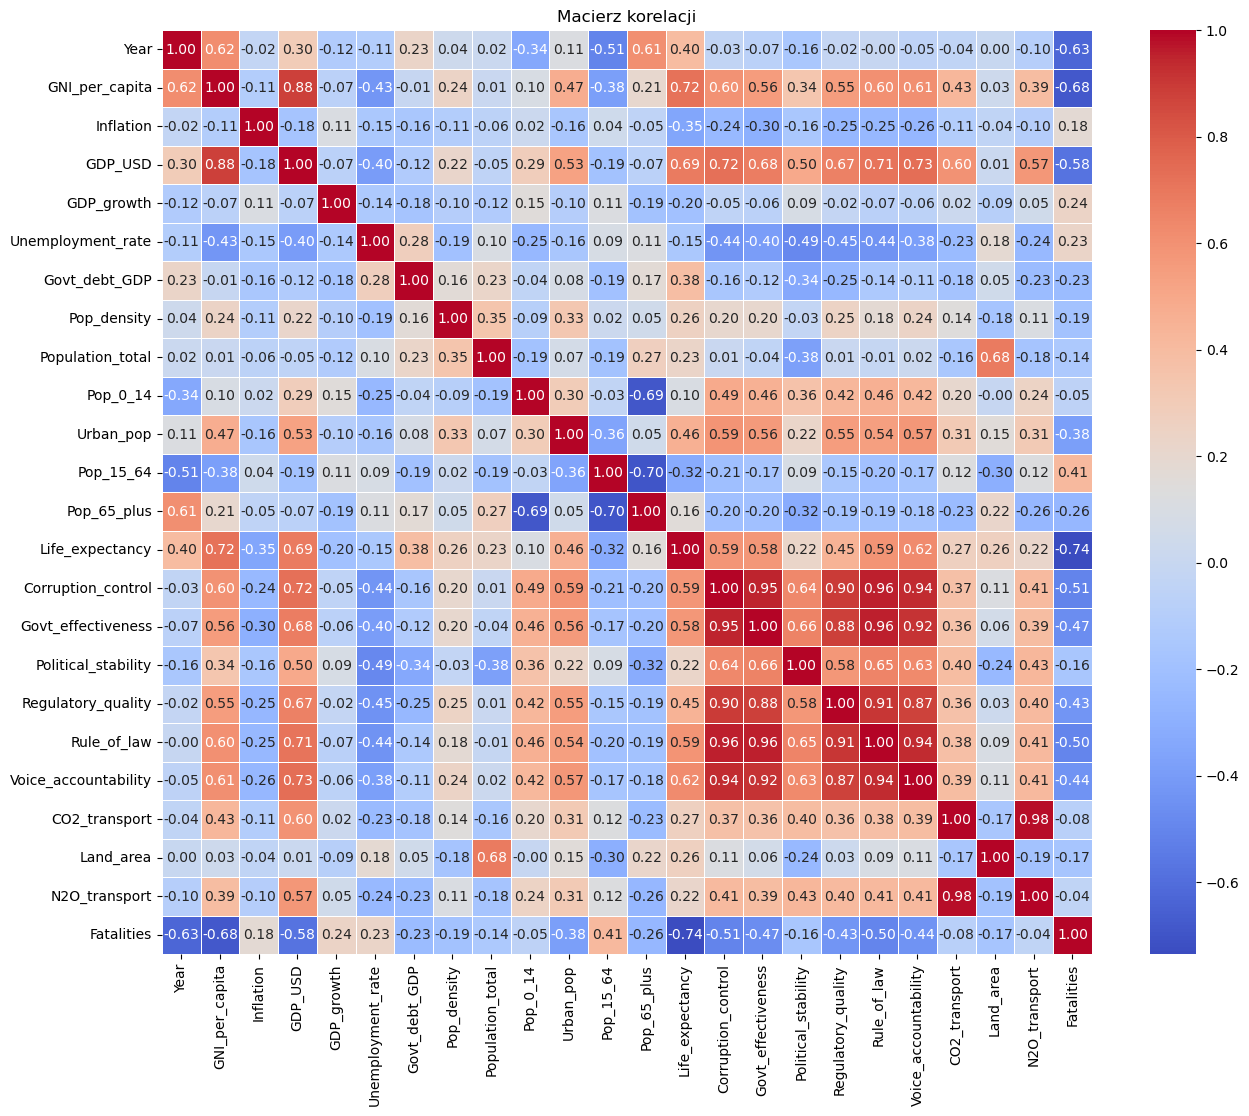

In [14]:
plot_corr_matrix()

Możemy zauważyć, że atrybuty "Corruption_control", "Govt_effectiveness", "Regulatory quality", "Rule of law" i "Voice_accountability" są mocno dodatnio skorelowane. Z tego powodu zostawimy tylko jeden atrybut z tych pięciu i będzie to atrybut, który będzie najmniej skorelowany z innymi cechami. Analogicznie postapimy z cechami "CO2_transport" i "N2O_transport" oraz "GNI_per_capita" i "GDP_USD".

In [15]:
group1 = ["Corruption_control", "Govt_effectiveness", "Regulatory_quality", "Rule_of_law", "Voice_accountability"]
group2 = ["CO2_transport", "N2O_transport"]
group3 = ["GNI_per_capita", "GDP_USD"]

data_no_country = data.drop(columns=['Country'])
correlation_matrix = data_no_country.corr()

scores_group1 = {}
for attr in group1:
 	scores_group1[attr] = np.sum(np.abs(correlation_matrix[attr])) - np.sum(np.abs(correlation_matrix[attr][group1]))

scores_group2 = {}
for attr in group2:
 	scores_group2[attr] = np.sum(np.abs(correlation_matrix[attr])) - np.sum(np.abs(correlation_matrix[attr][group2]))
	 
scores_group3 = {}
for attr in group3:
 	scores_group3[attr] = np.sum(np.abs(correlation_matrix[attr])) - np.sum(np.abs(correlation_matrix[attr][group3]))

print(f"Najmniej skorelowana cecha z pierwszej grupy: {min(scores_group1, key=scores_group1.get)}")
print(f"Najmniej skorelowana cecha z drugiej grupy: {min(scores_group2, key=scores_group2.get)}")
print(f"Najmniej skorelowana cecha z trzeciej grupy: {min(scores_group3, key=scores_group3.get)}")

Najmniej skorelowana cecha z pierwszej grupy: Regulatory_quality
Najmniej skorelowana cecha z drugiej grupy: CO2_transport
Najmniej skorelowana cecha z trzeciej grupy: GNI_per_capita


In [16]:
for attr in group1:
	if attr != "Regulatory_quality":
		data= data.drop([attr], axis=1)

for attr in group2:
	if attr != "CO2_transport":
		data= data.drop([attr], axis=1)

for attr in group3:
	if attr != "GNI_per_capita":
		data= data.drop([attr], axis=1)

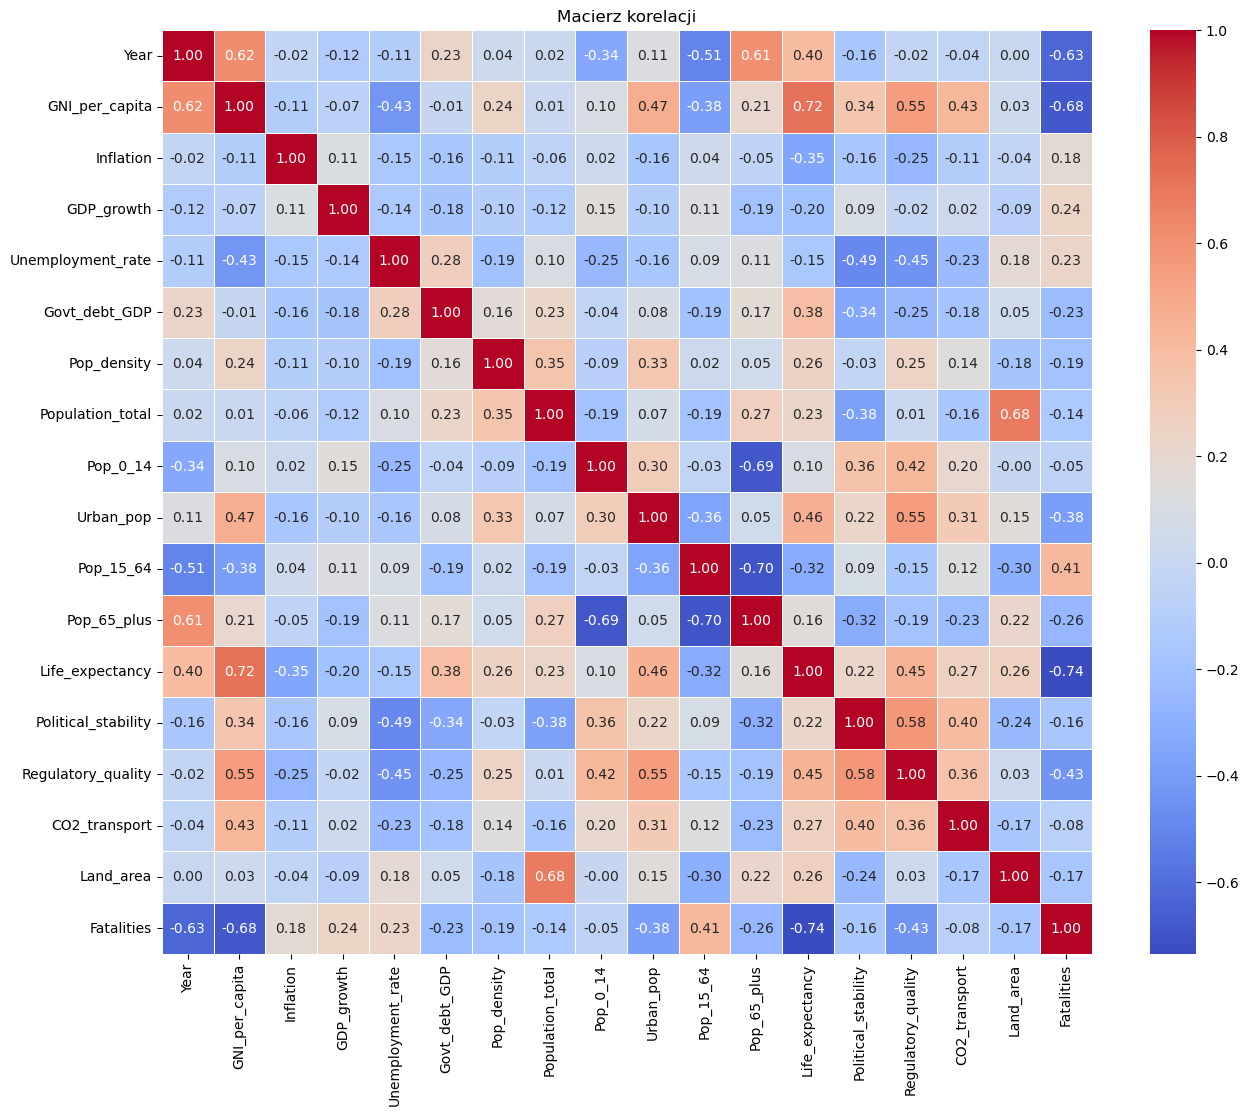

In [17]:
plot_corr_matrix()

##### Silne korelacje pozytywne
- Population_total i Land_area (0.68): Kraje o większej populacji mają zazwyczaj większą powierzchnię.
- Life_expectancy i GNI_per_capita (0.72): Wyższy dochód na mieszkańca wiąże się z dłuższą oczekiwaną długością życia.
- GNI_per_capita i Year (0.62): Co roku notowane są coraz większe dochody.

##### Silne korelacje negatywne
- Life_expectancy i Fatalities (-0.74): Dłuższa długość życia jest negatywnie skorelowana z liczba ofiar śmiertelnych w wypadkach drogowych. 
- Pop_15_64 i Pop_65_plus (-0.70): Wyższy odsetek osób w wieku produkcyjnym (15–64 lata) jest negatywnie skorelowany z odsetkiem osób w wieku 65+.
- Pop_65_plus i Pop_0_14 (-0.69): Kraje z większym odsetkiem osób starszych (65+) mają mniejszy odsetek dzieci (0–14).
- GNI_per_capita i Fatalities (-0.68): Wyższe dochody są negatywnie skorelowane z liczbą ofiar.
- Year i Fatalities (-0.63): Z roku na rok coraz mniej osób ginie na drogach.

##### Ciekawe obserwacje
- Unemployment_rate i Political stability (-0.49): Niższe wskaźniki bezrobocia są powiązane z wyższą stabilnością polityczną.
- Year i Pop_65_plus (0.61): Z roku na rok rośnie ilość ludzi w wieku 65+.
- Inflation i GNI_per_capita (0.11): Korelacja między inflacją a wzrostem PKB jest słaba, co sugeruje, że inne czynniki mają większy wpływ na wzrost gospodarczy.
- Political_stability i Regulatory_quality (0.58): Większa stabilność polityczna idzie w parze z wyższą jakością regulacji.
- Regulatory_quality i Life_expectancy (0.45): Wyższa jakośc regulacji koreluje z dłuższą oczekiwaną długością życia.

#### Przedstawienie najmocniej skorelowanych cech

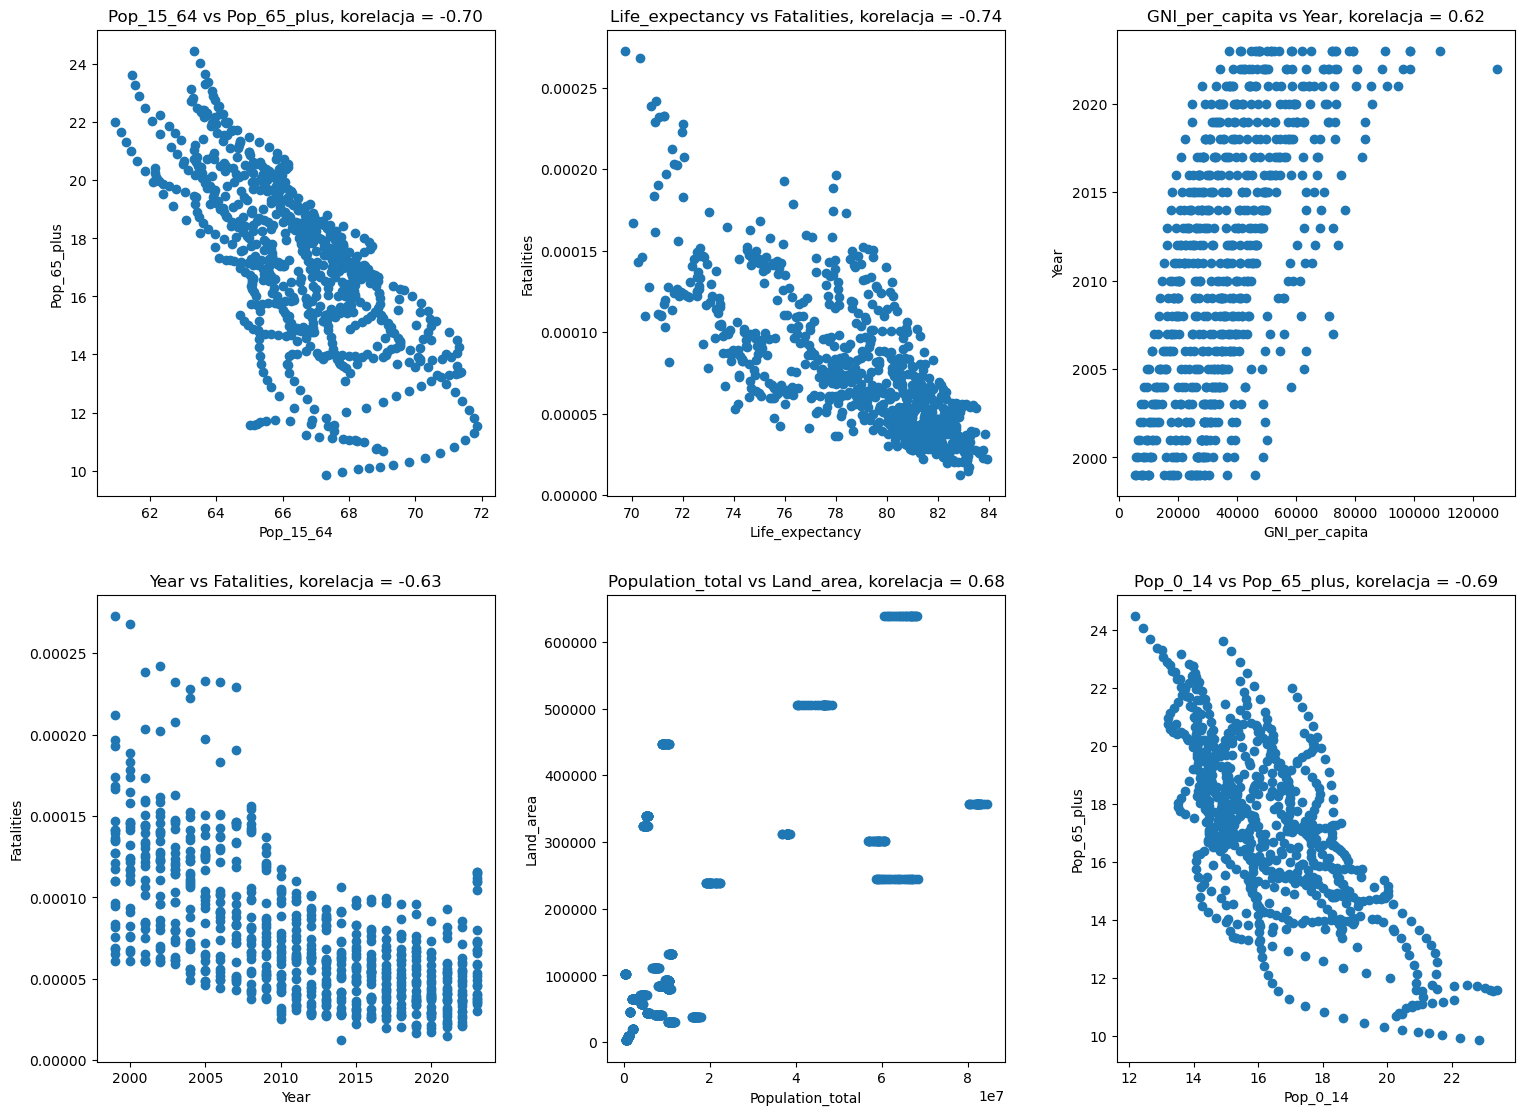

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
fig.tight_layout(pad=5)

axes[0, 0].scatter(data['Pop_15_64'], data['Pop_65_plus'])
axes[0, 0].set_xlabel('Pop_15_64')
axes[0, 0].set_ylabel('Pop_65_plus')
axes[0, 0].set_title('Pop_15_64 vs Pop_65_plus, korelacja = -0.70')

axes[0, 1].scatter(data['Life_expectancy'], data['Fatalities'])
axes[0, 1].set_xlabel('Life_expectancy')
axes[0, 1].set_ylabel('Fatalities')
axes[0, 1].set_title('Life_expectancy vs Fatalities, korelacja = -0.74')

axes[0, 2].scatter(data['GNI_per_capita'], data['Year'])
axes[0, 2].set_xlabel('GNI_per_capita')
axes[0, 2].set_ylabel('Year')
axes[0, 2].set_title('GNI_per_capita vs Year, korelacja = 0.62')

axes[1, 0].scatter(data['Year'], data['Fatalities'])
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Fatalities')
axes[1, 0].set_title('Year vs Fatalities, korelacja = -0.63')

axes[1, 1].scatter(data['Population_total'], data['Land_area'])
axes[1, 1].set_xlabel('Population_total')
axes[1, 1].set_ylabel('Land_area')
axes[1, 1].set_title('Population_total vs Land_area, korelacja = 0.68')

axes[1, 2].scatter(data['Pop_0_14'], data['Pop_65_plus'])
axes[1, 2].set_xlabel('Pop_0_14')
axes[1, 2].set_ylabel('Pop_65_plus')
axes[1, 2].set_title('Pop_0_14 vs Pop_65_plus, korelacja = -0.69')

plt.show()


### Zbadanie zakresów i stopnia zmienności z wizualizacjami

In [19]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,725.0,2.011000e+03,7.216081e+00,1.999000e+03,2.005000e+03,2.011000e+03,2.017000e+03,2.023000e+03
GNI_per_capita,725.0,3.707103e+04,1.797409e+04,5.530000e+03,2.512000e+04,3.426000e+04,4.647000e+04,1.280200e+05
Inflation,725.0,3.000078e+00,3.956570e+00,-4.447547e+00,1.083821e+00,2.216582e+00,3.530650e+00,4.580378e+01
GDP_growth,725.0,2.309816e+00,3.652856e+00,-1.483861e+01,9.333410e-01,2.449324e+00,4.107027e+00,2.447525e+01
Unemployment_rate,725.0,7.773910e+00,4.189480e+00,1.805000e+00,4.826000e+00,6.859000e+00,9.376000e+00,2.768600e+01
Govt_debt_GDP,725.0,6.743595e+01,4.270361e+01,3.811326e+00,3.584562e+01,5.663169e+01,9.258226e+01,2.532259e+02
Pop_density,725.0,1.222056e+02,1.008368e+02,2.701438e+00,5.819066e+01,1.010971e+02,1.356374e+02,4.783426e+02
Population_total,725.0,1.762109e+07,2.249231e+07,2.773810e+05,3.931947e+06,8.638167e+06,1.713130e+07,8.448227e+07
Pop_0_14,725.0,1.636465e+01,2.060742e+00,1.219839e+01,1.472646e+01,1.598171e+01,1.766121e+01,2.340109e+01
Urban_pop,725.0,7.339499e+01,1.187578e+01,5.072800e+01,6.670600e+01,7.353300e+01,8.236500e+01,9.818900e+01


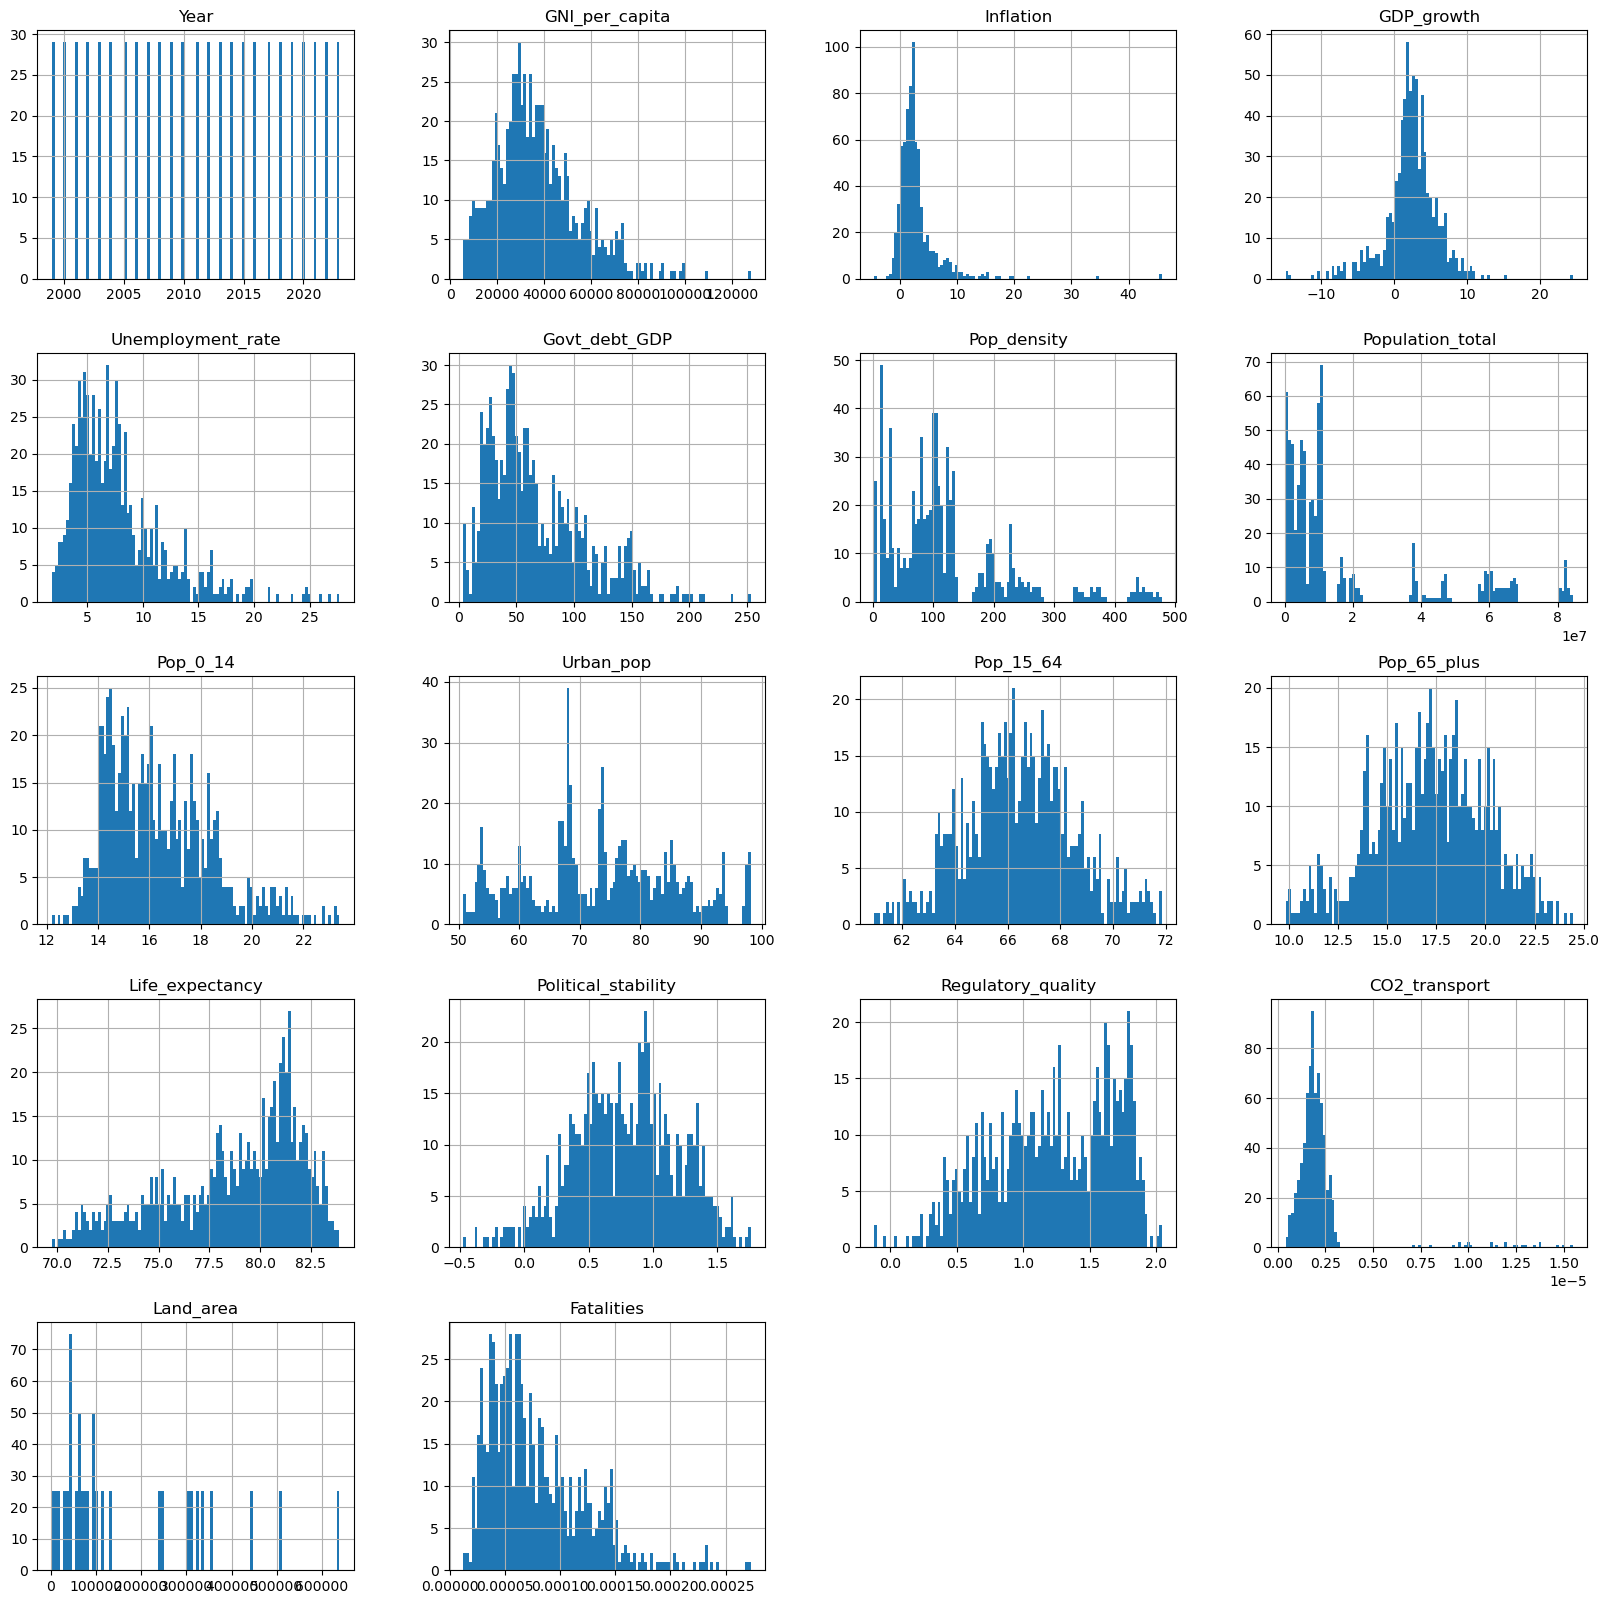

In [21]:
data_no_country = data.drop(columns=['Country'])
data_no_country.hist(bins=100, figsize=(20, 20))
plt.show()

##### Rok:
- Rozkład jednolity.
- Dane obejmują lata od 2000 do 2022.

##### GNI per capita:
- Rozkład prawoskośny, większość wartości poniżej 40 000 USD.
- Występują wartości odstające powyżej 100 000 USD.


##### Inflacja:
- Skupiona w zakresie 0–10%.
- Kilka ekstremalnych wartości wskazuje na odstające dane.


##### Wzrost PKB
- Większość danych w zakresie od 0% do 10%.
- Umiarkowane wartości odstające poniżej -10% i powyżej +10%.

##### Stopa bezrobocia:
- Większość wartości poniżej 10%.
- Rozkład prawoskośny z długim ogonem z wartościami powyżej 25%.

##### Dług publiczny w stosunku do PKB:
- Skupiony wokół 0–100%.
- Wartości odstające sięgają powyżej 200%.
- Rozkład prawoskośny.

##### Gęstość zaludnienia:
- Rozkład prawoskośny.
- Wielomodalność.
- Kilka państw przekracza 400 osób na km².

##### Liczba ludności:
- Wielomodalność.
- Duży zakres, od kilku milionów do kilkudziesięciu milionów.

##### Grupy wiekowe ludności (15-64, 65+):
- Rozkład normalny.
  
##### Grupy wiekowe ludności 0-14:
- Rozkład prawoskośny.

##### Oczekiwana długość życia:
- Skupiona wokół 80-82.5 lat.
- Rozkład lewoskośny.

##### Procent ludności miejskiej:
- Zakres od 50% do 100%.

##### Stabilność polityczna
- Rozkład normalny.
- Większośc wartości od 0 do 1.5

##### Jakość regulacji:
- Rozkład lewoskośny.
- Większośc wartości od 0.5 do 2

##### Emisje CO2 (transport):
- Rozkład skośny w prawo.
- Wartości odstające znacznie wyższe.

##### Powierzchnia kraju:
- Silnie skośna w prawo, większość krajów ma małą powierzchnię.
- Kilka dużych państw mocno odstaje.

##### Liczba ofiar śmiertelnych (Fatalities):
- Mocno prawoskośny z długim ogonem.
- Wartości około 6e-5.

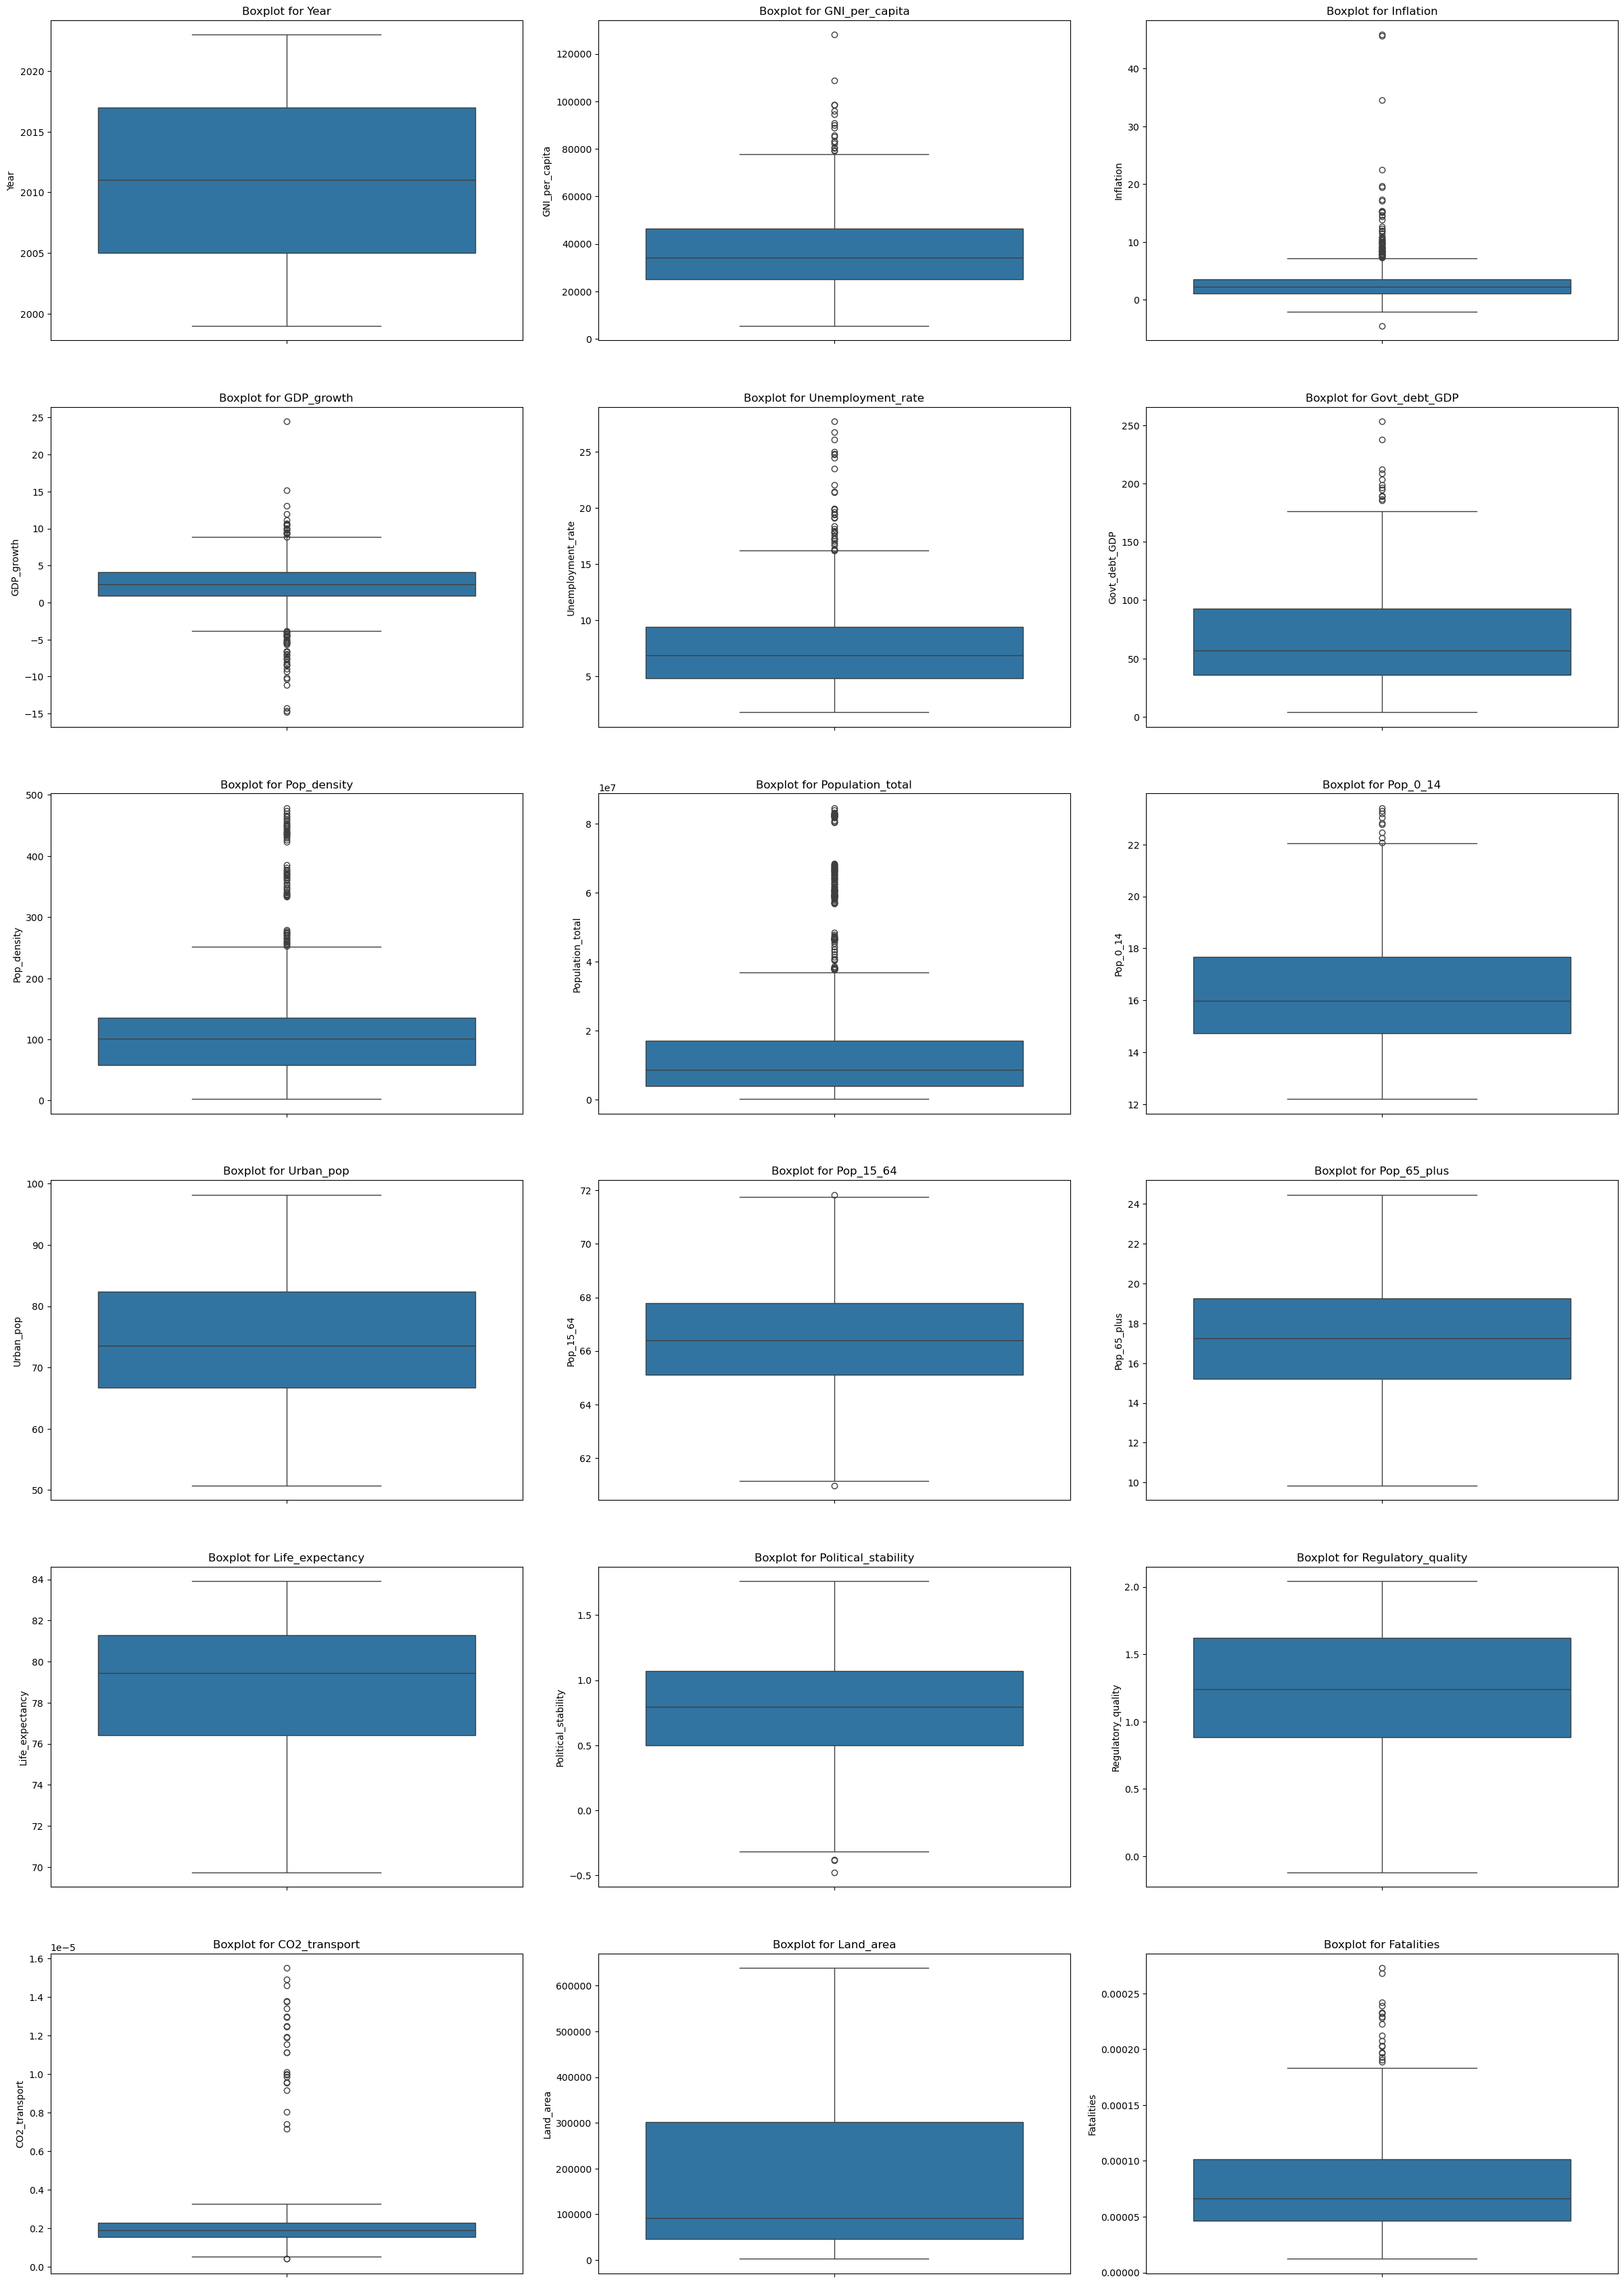

In [22]:
fig, axes = plt.subplots(6, 3, figsize=(25, 35))
fig.tight_layout(pad=5)
axes = axes.ravel()  

for i, col in enumerate(data_no_country.columns[:19]):
    sns.boxplot(data=data_no_country[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')
    
plt.show()

Podkreślają wyraźne wartości odstające dla takich zmiennych, jak:
- GNI per capita,
- Przyrost PKB,
- Inflacja, 
- Dług publiczny, 
- Bezrobocie,
- Populacja,
- Ilośc ludźi w przedziale 0-14,
- Gęstość zaludnienia, 
- Emisje CO2, 
- Liczba ofiar śmiertelnych.

Zakresy centralne (rozstęp międzykwartylowy) są na ogół wąskie dla większości zmiennych, co wskazuje na umiarkowaną zmienność danych w ich głównej części.

### Hipoteza

Kraje bardziej zamożne i bardziej rozwinięte będą miały mniej ofiar śmiertelych w wypadkach drogowych per capita.

## Model regresji

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Po rozmowie z prowadzącym przedmiot zdecydowaliśmy się dodać pochodzące z zewnętrznego źródła dane o liczbie samochodów przypadających na jedną osobe w państwie w danym roku

In [24]:
cars = pd.read_csv('estat_road_eqs_carhab_en.csv')

In [25]:
data['Cars_per_capita'] = data.apply(
    lambda row: cars.loc[
        (cars['Geopolitical entity (reporting)'] == row['Country']) & 
        (cars['TIME_PERIOD'] == row['Year']), 
        'OBS_VALUE'
    ].squeeze() / 1000 if not cars.loc[
        (cars['Geopolitical entity (reporting)'] == row['Country']) & 
        (cars['TIME_PERIOD'] == row['Year']), 
        'OBS_VALUE'
    ].empty else None,
    axis=1
)

In [26]:
medians = data.groupby('Country')['Cars_per_capita'].transform('median')
data['Cars_per_capita'] = data['Cars_per_capita'].fillna(medians)

Dodajemy kolumne z danymi dotyczącymi liczby zgonów z roku poprzedniego w każdym kraju

In [27]:
data['Previous_year_fatalities'] = data.groupby('Country')['Fatalities'].shift(1)
data = data.dropna(how="any")

Do stworzenia modelu będziemy wykorzystywać dane bez kolumny 'Country', żeby informacja o tym w jakim kraju się znajdujemy nie miała wpływu na model.

In [28]:
data_no_country = data.drop(columns=['Country'])
data_no_country.head()

,Year,GNI_per_capita,Inflation,GDP_growth,Unemployment_rate,Govt_debt_GDP,Pop_density,Population_total,Pop_0_14,Urban_pop,Pop_15_64,Pop_65_plus,Life_expectancy,Political_stability,Regulatory_quality,CO2_transport,Land_area,Fatalities,Cars_per_capita,Previous_year_fatalities
1,2000,29120.0,2.344863,3.375722,4.694,64.739782,95.514509,8011566,17.046335,60.213,67.540628,15.413033,78.126829,0.822056,1.475476,0.000002,83878,0.000122,0.511,0.000135
2,2001,29310.0,2.650001,1.267168,4.012,65.185856,95.880839,8042293,16.822817,59.934,67.742446,15.434743,78.575610,1.089649,1.475476,0.000002,83878,0.000119,0.519,0.000122
3,2002,31000.0,1.810358,1.651554,4.860,67.811873,96.353716,8081957,16.617735,59.655,67.949260,15.433002,78.678049,1.358955,1.538056,0.000003,83878,0.000118,0.492,0.000119
4,2003,32070.0,1.355554,0.941471,4.785,66.791019,96.824233,8121423,16.435424,59.375,68.117607,15.446970,78.631707,0.962002,1.537136,0.000003,83878,0.000115,0.498,0.000118
5,2004,33730.0,2.061206,2.735120,5.969,66.461798,97.426810,8171966,16.233091,59.094,68.058017,15.708897,79.180488,1.089649,1.514103,0.000003,83878,0.000107,0.501,0.000115


Ponieważ nie chcemy, aby dane z przyszłości nie powinny wpływać na przewidywanie przeszłości, to przed stworzeniem modelu posortujemy zbiór danych ze względu na chronologie. Zbiorem treningowym będzie początkowych 80 procent danych, a zbiorem testowym pozostałe 20 procent.

In [29]:
# Sortowanie danych
data_sorted = data_no_country.sort_values(by='Year')

In [30]:
def split_data(data, target_column, split_ratio=0.8):
    split_index = int(len(data) * split_ratio)
    
    train_data = data.iloc[:split_index]
    test_data = data.iloc[split_index:]

    X_train = train_data.drop([target_column], axis=1)
    y_train = train_data[target_column]
    X_test = test_data.drop([target_column], axis=1)
    y_test = test_data[target_column]
    
    return X_train, y_train, X_test, y_test

In [31]:
X_train, y_train, X_test, y_test = split_data(data_sorted, "Fatalities")

In [32]:
def scale_data(X_train, X_test, scaler):
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled

In [33]:
X_train, X_test = scale_data(X_train, X_test, StandardScaler())

In [34]:
feature_names = [col for col in data_no_country.columns if col != "Fatalities"]

In [35]:
def show_plot(y_test, y_pred):
    plt.scatter(y_test, y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.xlabel('Rzeczywiste wartości')
    plt.ylabel('Prognozowane wartości')
    plt.title('Rzeczywiste vs Prognozowane')
    plt.axis((1e-5, 1e-4,1e-5, 1e-4))
    plt.ticklabel_format(style='sci', axis='both', scilimits=(-4, -4))
    plt.show()

In [36]:
def summarize_coefficients(model, feature_names):
    coefficients = model.coef_ 

    coef_df = pd.DataFrame({
        'Cecha': feature_names,
        'Współczynnik': coefficients,
        'Moduł': abs(coefficients)
    })

    coef_df = coef_df.sort_values(by='Moduł', ascending=False)

    return coef_df

#### Punkt odniesienia

In [37]:
print(f"R^2 na zbiorze testowym: {r2_score(data.iloc[:,-3], data.iloc[:,-1])}")
print(f"MSE na zbiorze testowym: {mean_squared_error(data.iloc[:,-3], data.iloc[:,-1])}")
print(f"MAE na zbiorze testowym: {mean_absolute_error(data.iloc[:,-3], data.iloc[:,-1])}",)

R^2 na zbiorze testowym: 0.9152568013766927
MSE na zbiorze testowym: 1.50296827959409e-10
MAE na zbiorze testowym: 8.202005676126758e-06


## Regresja wieloraka

#### Model bez regularyzacji

In [38]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = regressor.predict(X_test)
print(f"Wyniki:")
print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Wyniki:
R² dla zbioru testowego: 0.4979799522371732
MSE: 2.5250488523734805e-10
MAE: 1.0107486010106922e-05


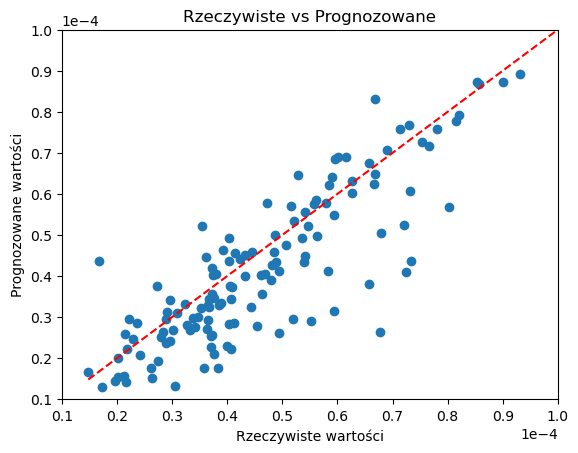

In [40]:
show_plot(y_test, y_pred)

In [41]:
coef_summary = summarize_coefficients(regressor, feature_names)
print(coef_summary) 

                       Cecha  Współczynnik         Moduł
11               Pop_65_plus  2.508084e-02  2.508084e-02
8                   Pop_0_14  2.007071e-02  2.007071e-02
10                 Pop_15_64  1.810967e-02  1.810967e-02
18  Previous_year_fatalities  3.703261e-05  3.703261e-05
3                 GDP_growth  3.673346e-06  3.673346e-06
0                       Year -3.309423e-06  3.309423e-06
14        Regulatory_quality -3.303263e-06  3.303263e-06
12           Life_expectancy -3.174506e-06  3.174506e-06
2                  Inflation -1.273544e-06  1.273544e-06
1             GNI_per_capita  8.933743e-07  8.933743e-07
5              Govt_debt_GDP  6.129443e-07  6.129443e-07
13       Political_stability  5.203560e-07  5.203560e-07
15             CO2_transport  5.128345e-07  5.128345e-07
9                  Urban_pop  4.370776e-07  4.370776e-07
6                Pop_density  3.390134e-07  3.390134e-07
16                 Land_area  1.751587e-07  1.751587e-07
4          Unemployment_rate -1

#### Regularyzacja metodą Lasso

In [42]:
lasso = LassoCV(cv=5, random_state=0, n_alphas=1000, max_iter=10000, tol=0.00001, n_jobs=-1)
lasso.fit(X_train, y_train)

LassoCV(cv=5, max_iter=10000, n_alphas=1000, n_jobs=-1, random_state=0,
        tol=1e-05)

In [43]:
y_pred = lasso.predict(X_test)
print(f"Wyniki dla regularyzacji L1 (alpha={lasso.alpha_}):")
print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Wyniki dla regularyzacji L1 (alpha=5.565246446100539e-08):
R² dla zbioru testowego: 0.4769286899430232
MSE: 2.6309320057131437e-10
MAE: 1.0304491196963346e-05


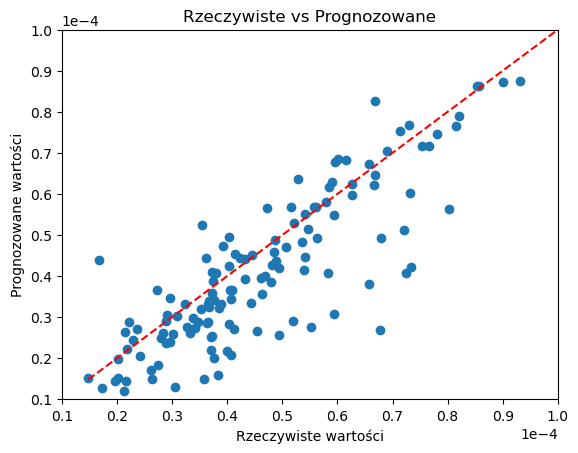

In [44]:
show_plot(y_test, y_pred)

In [45]:
coef_summary = summarize_coefficients(lasso, feature_names)
print(coef_summary) 

                       Cecha  Współczynnik         Moduł
18  Previous_year_fatalities  3.715946e-05  3.715946e-05
3                 GDP_growth  3.650507e-06  3.650507e-06
14        Regulatory_quality -2.954116e-06  2.954116e-06
0                       Year -2.898442e-06  2.898442e-06
12           Life_expectancy -2.287227e-06  2.287227e-06
2                  Inflation -1.098664e-06  1.098664e-06
11               Pop_65_plus  7.665440e-07  7.665440e-07
15             CO2_transport  5.888060e-07  5.888060e-07
13       Political_stability  4.139171e-07  4.139171e-07
9                  Urban_pop  4.029857e-07  4.029857e-07
6                Pop_density  2.824636e-07  2.824636e-07
5              Govt_debt_GDP  2.324565e-07  2.324565e-07
10                 Pop_15_64 -1.184782e-07  1.184782e-07
4          Unemployment_rate -9.871388e-08  9.871388e-08
7           Population_total -0.000000e+00  0.000000e+00
8                   Pop_0_14 -0.000000e+00  0.000000e+00
1             GNI_per_capita  0

#### Regularyzacja z użyciem regresji grzbietowej

In [46]:
alphas = [(10**x)*1e-10 for x in range(12)]
alphas = np.concatenate([np.array(alphas), np.array(alphas)/2, np.array(alphas)/4, np.array(alphas)/8])
ridge = RidgeCV(cv=5, alphas=alphas)
ridge.fit(X_train, y_train)

RidgeCV(alphas=array([1.00e-10, 1.00e-09, 1.00e-08, 1.00e-07, 1.00e-06, 1.00e-05,
       1.00e-04, 1.00e-03, 1.00e-02, 1.00e-01, 1.00e+00, 1.00e+01,
       5.00e-11, 5.00e-10, 5.00e-09, 5.00e-08, 5.00e-07, 5.00e-06,
       5.00e-05, 5.00e-04, 5.00e-03, 5.00e-02, 5.00e-01, 5.00e+00,
       2.50e-11, 2.50e-10, 2.50e-09, 2.50e-08, 2.50e-07, 2.50e-06,
       2.50e-05, 2.50e-04, 2.50e-03, 2.50e-02, 2.50e-01, 2.50e+00,
       1.25e-11, 1.25e-10, 1.25e-09, 1.25e-08, 1.25e-07, 1.25e-06,
       1.25e-05, 1.25e-04, 1.25e-03, 1.25e-02, 1.25e-01, 1.25e+00]),
        cv=5)

In [47]:
y_pred = ridge.predict(X_test)
print(f"Wyniki dla regularyzacji z użyciem regresji grzbietowej (alpha={ridge.alpha_}):")
print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Wyniki dla regularyzacji z użyciem regresji grzbietowej (alpha=1.0):
R² dla zbioru testowego: 0.49159156827439854
MSE: 2.5571809986206483e-10
MAE: 1.0202059252231973e-05


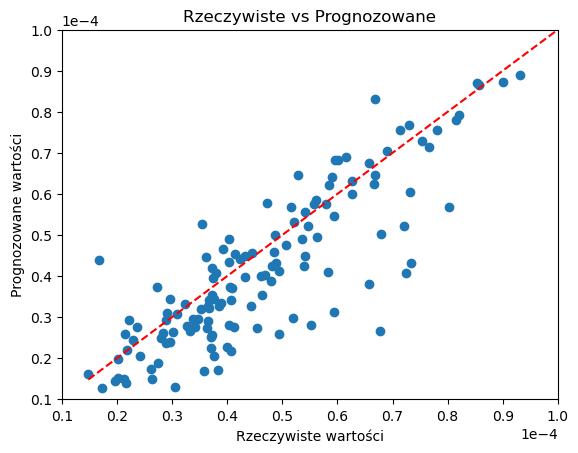

In [48]:
show_plot(y_test, y_pred)

In [49]:
coef_summary = summarize_coefficients(ridge, feature_names)
print(coef_summary) 

                       Cecha  Współczynnik         Moduł
18  Previous_year_fatalities  3.678163e-05  3.678163e-05
3                 GDP_growth  3.685258e-06  3.685258e-06
0                       Year -3.414225e-06  3.414225e-06
14        Regulatory_quality -3.353722e-06  3.353722e-06
12           Life_expectancy -3.176654e-06  3.176654e-06
2                  Inflation -1.288661e-06  1.288661e-06
1             GNI_per_capita  7.650751e-07  7.650751e-07
5              Govt_debt_GDP  5.813411e-07  5.813411e-07
15             CO2_transport  5.558847e-07  5.558847e-07
11               Pop_65_plus  5.492995e-07  5.492995e-07
13       Political_stability  4.970492e-07  4.970492e-07
9                  Urban_pop  4.542505e-07  4.542505e-07
10                 Pop_15_64 -3.755917e-07  3.755917e-07
8                   Pop_0_14 -3.462973e-07  3.462973e-07
6                Pop_density  3.103947e-07  3.103947e-07
4          Unemployment_rate -1.825153e-07  1.825153e-07
16                 Land_area  1

#### Regularyzacja metodą Lasso i Ridge

In [50]:
l1_ratios = [x/100 for x in range(5, 100, 5)]
elastic_net = ElasticNetCV(cv=5, random_state=0, n_alphas=1000, max_iter=10000, tol=0.00001, n_jobs=-1, l1_ratio=l1_ratios)
elastic_net.fit(X_train, y_train)

ElasticNetCV(cv=5,
             l1_ratio=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
                       0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
             max_iter=10000, n_alphas=1000, n_jobs=-1, random_state=0,
             tol=1e-05)

In [51]:
y_pred = elastic_net.predict(X_test)
print(f"Wyniki dla ElasticNeta (alpha={elastic_net.alpha_}, l1_ratio={elastic_net.l1_ratio_}):")
print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Wyniki dla ElasticNeta (alpha=5.858154153790043e-08, l1_ratio=0.95):
R² dla zbioru testowego: 0.47692868736072247
MSE: 2.63093201870154e-10
MAE: 1.0304491248962385e-05


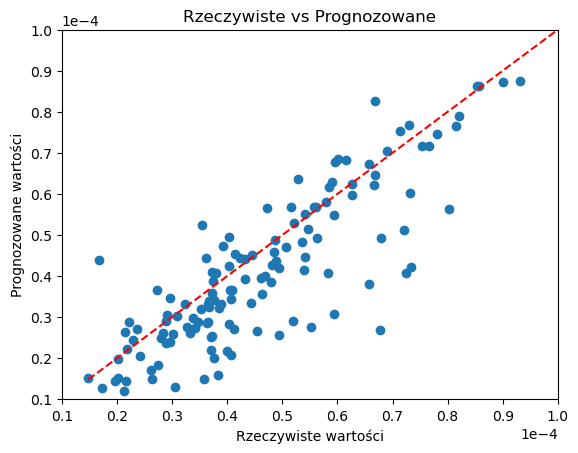

In [52]:
show_plot(y_test, y_pred)

In [53]:
coef_summary = summarize_coefficients(elastic_net, feature_names)
print(coef_summary) 

                       Cecha  Współczynnik         Moduł
18  Previous_year_fatalities  3.715946e-05  3.715946e-05
3                 GDP_growth  3.650507e-06  3.650507e-06
14        Regulatory_quality -2.954116e-06  2.954116e-06
0                       Year -2.898442e-06  2.898442e-06
12           Life_expectancy -2.287227e-06  2.287227e-06
2                  Inflation -1.098664e-06  1.098664e-06
11               Pop_65_plus  7.665441e-07  7.665441e-07
15             CO2_transport  5.888061e-07  5.888061e-07
13       Political_stability  4.139171e-07  4.139171e-07
9                  Urban_pop  4.029856e-07  4.029856e-07
6                Pop_density  2.824635e-07  2.824635e-07
5              Govt_debt_GDP  2.324565e-07  2.324565e-07
10                 Pop_15_64 -1.184781e-07  1.184781e-07
4          Unemployment_rate -9.871389e-08  9.871389e-08
7           Population_total -0.000000e+00  0.000000e+00
8                   Pop_0_14 -0.000000e+00  0.000000e+00
1             GNI_per_capita  0

## Regresja wielomianowa z wielomianową kombinacją cech

#### Model bez regularyzacji

In [54]:
degrees = [2, 3]
regressors = {}

for degree in degrees:
	poly = PolynomialFeatures(degree=degree)
	X_train_poly = poly.fit_transform(X_train)
	X_test_poly = poly.transform(X_test)
	regressor = LinearRegression()
	regressor.fit(X_train_poly, y_train)
	y_pred = regressor.predict(X_test_poly)
	regressors[str(degree)] = [regressor, y_pred, y_test]

In [55]:
for regressor in regressors:
	model = regressors[regressor][0]
	y_pred = regressors[regressor][1]
	y_test = regressors[regressor][2]
	print(f"Wyniki dla wielomianu stopnia {regressor}:")
	print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
	print("MSE:", mean_squared_error(y_test, y_pred))
	print("MAE:", mean_absolute_error(y_test, y_pred))
	print("\n")

Wyniki dla wielomianu stopnia 2:
R² dla zbioru testowego: -0.4419506940620115
MSE: 7.252690328694938e-10
MAE: 1.83785917926238e-05


Wyniki dla wielomianu stopnia 3:
R² dla zbioru testowego: -15.262381067389416
MSE: 8.17961490463658e-09
MAE: 6.290168940953838e-05




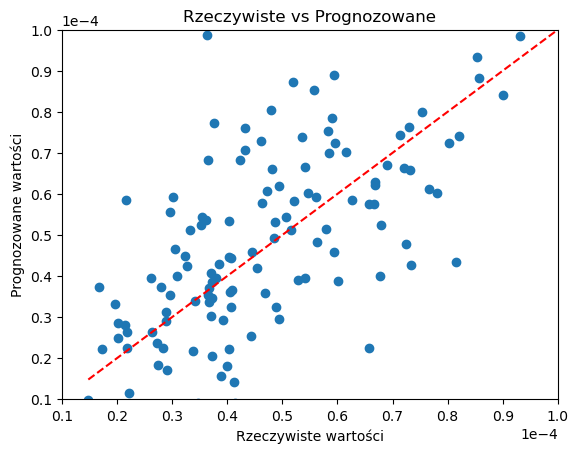

In [56]:
best_regressor = regressors["2"]
show_plot(best_regressor[2], best_regressor[1])

In [57]:
# get featrue names
df = pd.DataFrame(X_train, columns=feature_names)
poly = PolynomialFeatures(degree=2)
poly_df = poly.fit_transform(df)

coef_summary = summarize_coefficients(best_regressor[0], poly.get_feature_names_out())  
print(coef_summary[:20])

                            Cecha  Współczynnik        Moduł
147          Pop_0_14 Pop_65_plus  -4445.805411  4445.805411
166         Pop_15_64 Pop_65_plus  -4010.762210  4010.762210
146            Pop_0_14 Pop_15_64  -3210.312296  3210.312296
174                 Pop_65_plus^2  -2777.154768  2777.154768
144                    Pop_0_14^2  -1779.265707  1779.265707
165                   Pop_15_64^2  -1448.083994  1448.083994
136  Population_total Pop_65_plus     -1.879046     1.879046
133     Population_total Pop_0_14     -1.503744     1.503744
135    Population_total Pop_15_64     -1.356822     1.356822
175   Pop_65_plus Life_expectancy      1.191574     1.191574
148      Pop_0_14 Life_expectancy      0.953561     0.953561
12                    Pop_65_plus     -0.942423     0.942423
167     Pop_15_64 Life_expectancy      0.860411     0.860411
31               Year Pop_65_plus     -0.850820     0.850820
9                        Pop_0_14     -0.754203     0.754203
157         Urban_pop Po

#### Regularyzacja metodą Lasso

In [58]:
degrees = [2, 3]
lassos = {}

for degree in degrees:
	poly = PolynomialFeatures(degree=degree)
	X_train_poly = poly.fit_transform(X_train)
	X_test_poly = poly.transform(X_test)
	lasso = LassoCV(cv=5, random_state=0, n_alphas=100, max_iter=1000, tol=0.0001, n_jobs=-1)
	lasso.fit(X_train_poly, y_train)
	y_pred = lasso.predict(X_test_poly)
	lassos[str(degree)] = [lasso, y_pred, y_test]

c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.281e-10, tolerance: 8.734e-11
  model = cd_fast.enet_coordinate_descent(
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.720e-10, tolerance: 8.918e-11
  model = cd_fast.enet_coordinate_descent(
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.130e-10, toleranc

In [59]:
for lasso in lassos:
	model = lassos[lasso][0]
	y_pred = lassos[lasso][1]
	y_test = lassos[lasso][2]
	print(f"Wyniki dla wielomianu stopnia {lasso} (alpha={model.alpha_}):")
	print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
	print("MSE:", mean_squared_error(y_test, y_pred))
	print("MAE:", mean_absolute_error(y_test, y_pred))
	print("\n")

Wyniki dla wielomianu stopnia 2 (alpha=6.306749198597784e-07):
R² dla zbioru testowego: 0.6269374424428065
MSE: 1.8764214437674087e-10
MAE: 8.404465682639329e-06


Wyniki dla wielomianu stopnia 3 (alpha=8.467288381077802e-07):
R² dla zbioru testowego: 0.32713098724069767
MSE: 3.384381034257495e-10
MAE: 1.1999667909835449e-05




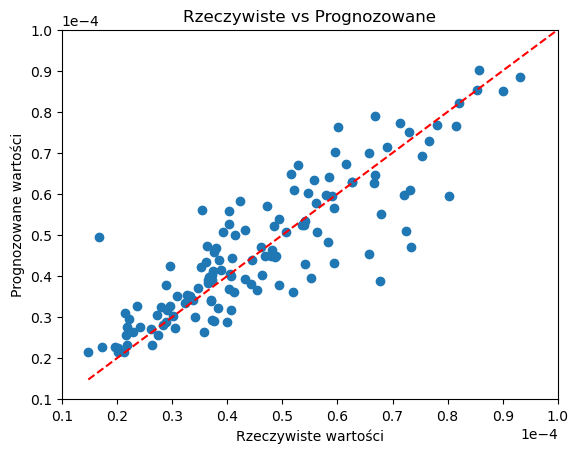

In [60]:
best_lasso = lassos["2"]
show_plot(best_lasso[2], best_lasso[1])

In [61]:
# get featrue names
df = pd.DataFrame(X_train, columns=feature_names)
poly = PolynomialFeatures(degree=2)
poly_df = poly.fit_transform(df)

coef_summary = summarize_coefficients(best_lasso[0], poly.get_feature_names_out())
print(coef_summary[:20])

                                         Cecha  Współczynnik         Moduł
19                    Previous_year_fatalities  3.714178e-05  3.714178e-05
4                                   GDP_growth  2.198887e-06  2.198887e-06
1                                         Year -1.703078e-06  1.703078e-06
13                             Life_expectancy -1.495305e-06  1.495305e-06
15                          Regulatory_quality -1.453229e-06  1.453229e-06
83                  GDP_growth Life_expectancy -1.262508e-06  1.262508e-06
73          Inflation Previous_year_fatalities -1.153163e-06  1.153163e-06
208   Cars_per_capita Previous_year_fatalities -5.687856e-07  5.687856e-07
38               Year Previous_year_fatalities -4.976184e-07  4.976184e-07
20                                      Year^2  3.570838e-07  3.570838e-07
89         GDP_growth Previous_year_fatalities  3.496465e-07  3.496465e-07
111                  Govt_debt_GDP Pop_65_plus  1.721365e-07  1.721365e-07
198         Regulatory_qu

#### Regularyzacja metodą Ridge

In [62]:
alphas = [(10**x)*1e-10 for x in range(12)]
alphas = np.concatenate([np.array(alphas), np.array(alphas)/2, np.array(alphas)/4, np.array(alphas)/8])

degrees = [2, 3]
ridges = {}

for degree in degrees:
	poly = PolynomialFeatures(degree=degree)
	X_train_poly = poly.fit_transform(X_train)
	X_test_poly = poly.transform(X_test)
	ridge = RidgeCV(cv=5, alphas=alphas)
	ridge.fit(X_train_poly, y_train)
	y_pred = ridge.predict(X_test_poly)
	ridges[str(degree)] = [ridge, y_pred, y_test]

c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=8.99131e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=8.88149e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=8.846e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=8.40864e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204:

In [63]:
for ridge in ridges:
	model = ridges[ridge][0]
	y_pred = ridges[ridge][1]
	y_test = ridges[ridge][2]
	print(f"Wyniki dla wielomianu stopnia {ridge} (alpha={model.alpha_}):")
	print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
	print("MSE:", mean_squared_error(y_test, y_pred))
	print("MAE:", mean_absolute_error(y_test, y_pred))
	print("\n")

Wyniki dla wielomianu stopnia 2 (alpha=10.0):
R² dla zbioru testowego: 0.5160561142984088
MSE: 2.4341297895363646e-10
MAE: 1.0119568986972238e-05


Wyniki dla wielomianu stopnia 3 (alpha=5.0):
R² dla zbioru testowego: -1.3303301425151721
MSE: 1.1721040779608826e-09
MAE: 2.4477829790763235e-05




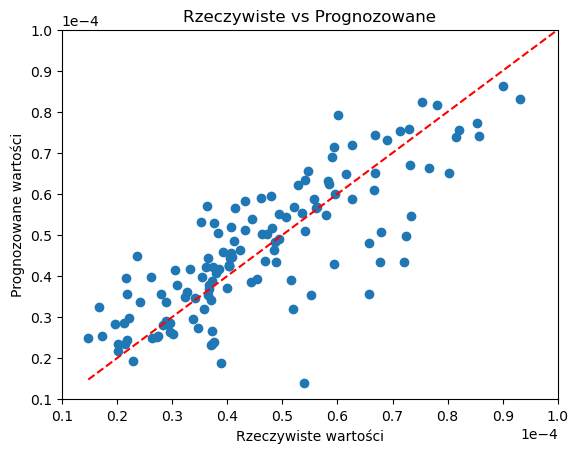

In [64]:
best_ridge = ridges["2"]
show_plot(best_ridge[2], best_ridge[1])

In [65]:
# get featrue names
df = pd.DataFrame(X_train, columns=feature_names)
poly = PolynomialFeatures(degree=2)
poly_df = poly.fit_transform(df)

coef_summary = summarize_coefficients(best_ridge[0], poly.get_feature_names_out())
print(coef_summary[:30])

                                        Cecha  Współczynnik     Moduł
19                   Previous_year_fatalities      0.000018  0.000018
1                                        Year     -0.000010  0.000010
13                            Life_expectancy     -0.000008  0.000008
35                         Year CO2_transport     -0.000006  0.000006
2                              GNI_per_capita     -0.000006  0.000006
148                  Pop_0_14 Life_expectancy     -0.000004  0.000004
5                           Unemployment_rate     -0.000003  0.000003
181      Pop_65_plus Previous_year_fatalities      0.000003  0.000003
9                                    Pop_0_14     -0.000003  0.000003
38              Year Previous_year_fatalities     -0.000003  0.000003
175               Pop_65_plus Life_expectancy      0.000003  0.000003
114          Govt_debt_GDP Regulatory_quality      0.000003  0.000003
4                                  GDP_growth      0.000003  0.000003
208  Cars_per_capita

#### Regularyzacja metodą Lasso i Ridge

In [66]:
l1_ratios = [x/100 for x in range(5, 100, 5)]

degrees = [2, 3]
elastic_nets = {}

for degree in degrees:
	poly = PolynomialFeatures(degree=degree)
	X_train_poly = poly.fit_transform(X_train)
	X_test_poly = poly.transform(X_test)
	elastic_net = ElasticNetCV(cv=5, random_state=0, n_alphas=100, max_iter=1000, tol=0.0001, n_jobs=-1, l1_ratio=l1_ratios)
	elastic_net.fit(X_train_poly, y_train)
	y_pred = elastic_net.predict(X_test_poly)
	elastic_nets[str(degree)] = [elastic_net, y_pred, y_test]

c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.293e-10, tolerance: 8.734e-11
  model = cd_fast.enet_coordinate_descent(
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.716e-10, tolerance: 8.918e-11
  model = cd_fast.enet_coordinate_descent(
c:\Users\janbb\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.139e-10, toleranc

In [67]:
for elastic_net in elastic_nets:
	model = elastic_nets[elastic_net][0]
	y_pred = elastic_nets[elastic_net][1]
	y_test = elastic_nets[elastic_net][2]
	print(f"Wyniki dla wielomianu stopnia {elastic_net} (alpha={model.alpha_}, l1_ratio={model.l1_ratio_}):")
	print("R² dla zbioru testowego:", r2_score(y_test, y_pred))
	print("MSE:", mean_squared_error(y_test, y_pred))
	print("MAE:", mean_absolute_error(y_test, y_pred))
	print("\n")

Wyniki dla wielomianu stopnia 2 (alpha=1.261349839719557e-05, l1_ratio=0.05):
R² dla zbioru testowego: 0.626933309346345
MSE: 1.8764422323206213e-10
MAE: 8.40448679921187e-06


Wyniki dla wielomianu stopnia 3 (alpha=8.912935137976635e-07, l1_ratio=0.95):
R² dla zbioru testowego: 0.3271305723061526
MSE: 3.3843831212856954e-10
MAE: 1.1999672938370949e-05




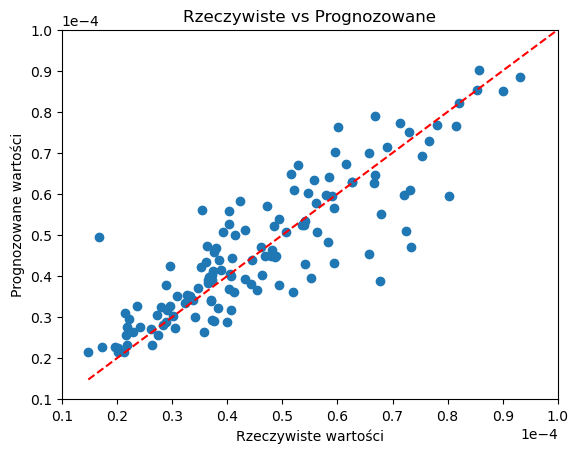

In [68]:
best_elastic_net = elastic_nets["2"]
show_plot(best_elastic_net[2], best_elastic_net[1])

In [69]:
# get featrue names
df = pd.DataFrame(X_train, columns=feature_names)
poly = PolynomialFeatures(degree=2)
poly_df = poly.fit_transform(df)

coef_summary = summarize_coefficients(best_elastic_net[0], poly.get_feature_names_out())
print(coef_summary[:20])

                                         Cecha  Współczynnik         Moduł
19                    Previous_year_fatalities  3.713918e-05  3.713918e-05
4                                   GDP_growth  2.198869e-06  2.198869e-06
1                                         Year -1.704148e-06  1.704148e-06
13                             Life_expectancy -1.496476e-06  1.496476e-06
15                          Regulatory_quality -1.453964e-06  1.453964e-06
83                  GDP_growth Life_expectancy -1.262324e-06  1.262324e-06
73          Inflation Previous_year_fatalities -1.153054e-06  1.153054e-06
208   Cars_per_capita Previous_year_fatalities -5.687232e-07  5.687232e-07
38               Year Previous_year_fatalities -4.986524e-07  4.986524e-07
20                                      Year^2  3.566351e-07  3.566351e-07
89         GDP_growth Previous_year_fatalities  3.499490e-07  3.499490e-07
111                  Govt_debt_GDP Pop_65_plus  1.722810e-07  1.722810e-07
198         Regulatory_qu

### Algorytm zachłanny doboru cech

Na bazie stworzonych wcześniej macierzy X_train_poly i X_test_poly przeprowadzimy dobór kolejnych cech algorytmem zachłannym. Algorytm w każdym kroku będzie dobierał te cechę której wybór minimalizuje średni błąd kwadratowy. W pierwszym kroku wybieramy jedną z 210 cech (19 cech podstawowych, 19 kwadratów cech, 171 iloczynów dwóch cech i stała) i później dobieramy kolejną która będzie spowoduje najmniejszy wzrost MSE.

In [70]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


# get featrue names
df = pd.DataFrame(X_train, columns=feature_names)
poly_2 = PolynomialFeatures(degree=2)
poly_df = poly_2.fit_transform(df)
feature_names = poly_2.get_feature_names_out()

#### Model bez regularyzacji

In [71]:
model = LinearRegression()

selected_features = []  
remaining_features = list(range(len(feature_names))) 
results = [] 

while remaining_features:
    best_feature = None
    best_mse = float('inf')
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        X_tmp = X_train_poly[:, current_features]
        X_tmp_test = X_test_poly[:, current_features]
        
        
        model.fit(X_tmp, y_train)
        
        mse_test = mean_squared_error(y_test, model.predict(X_tmp_test))
        
        if mse_test < best_mse:
            best_mse = mse_test
            best_feature = feature

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    results.append({
        'step': len(selected_features),
        'selected_features': [feature_names[i] for i in selected_features],  
        'mse': best_mse
    })

results_greedy_df = pd.DataFrame(results)
top_results = results_greedy_df.sort_values(by='mse', ascending=True).head(1)
selected_feature_names = top_results.iloc[0, 1]
selected_feature_indices = [i for i, feature in enumerate(feature_names) if feature in selected_feature_names]

X_train_selected = X_train_poly[:, selected_feature_indices]
X_test_selected = X_test_poly[:, selected_feature_indices]

model.fit(X_train_selected, y_train)

y_pred = model.predict(X_test_selected)

r2_train = model.score(X_train_selected, y_train)
r2_test = r2_score(y_test, y_pred)

print(f"R^2 na zbiorze treningowym: {r2_train}")
print(f"R^2 na zbiorze testowym: {r2_test}")
print(f"MSE na zbiorze testowym: {mean_squared_error(y_test, y_pred)}")
print(f"MAE na zbiorze testowym: {mean_absolute_error(y_test, y_pred)}",)


R^2 na zbiorze treningowym: 0.9569536105664869
R^2 na zbiorze testowym: 0.8042462686595905
MSE na zbiorze testowym: 9.845976009755842e-11
MAE na zbiorze testowym: 7.05699424046031e-06


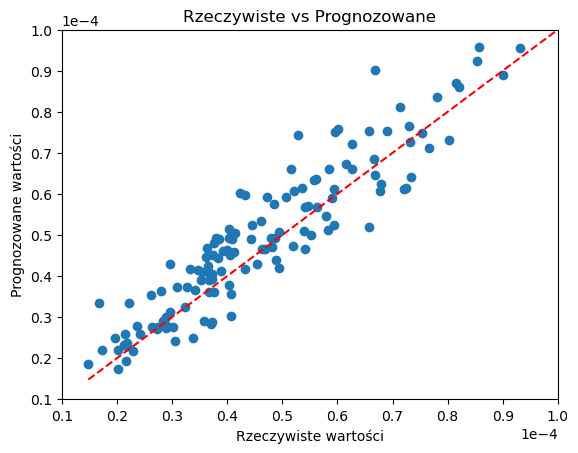

Porównanie prognozowanych wartości z rzeczywistymi dla modelu regresji wielomianowej:
4.099758587180596e-05 3.54838137357843e-05
4.704395829640786e-05 4.803525779018137e-05
7.650455804504423e-05 7.30581835866058e-05
5.679291669602392e-05 5.622779393819121e-05
4.391055486908429e-05 4.884156896357712e-05
6.849240744897558e-05 6.656795998191929e-05
4.668120535807695e-05 4.684726889431436e-05
7.521879554146037e-05 6.897193155894331e-05
3.60000224021462e-05 3.66577376312569e-05
4.054005898945262e-05 3.723360706646763e-05


In [72]:
show_plot(y_test, y_pred)

print(f"Porównanie prognozowanych wartości z rzeczywistymi dla modelu regresji wielomianowej:")
for i in range(10):
	print(y_pred[i], np.array(y_test)[i])

In [73]:
coef_summary = summarize_coefficients(model, selected_feature_names)  
print(coef_summary[:10]) 

                                        Cecha  Współczynnik        Moduł
54                       Pop_0_14 Pop_65_plus   5506.317598  5506.317598
59                                Pop_65_plus   4968.497841  4968.497841
53                        Pop_15_64 Land_area   3976.088057  3976.088057
62             Population_total CO2_transport   3440.332145  3440.332145
52           Regulatory_quality CO2_transport   2203.241739  2203.241739
58                                  Land_area   1793.865370  1793.865370
63  Population_total Previous_year_fatalities      0.110888     0.110888
55                                Pop_15_64^2      0.088741     0.088741
60                    Govt_debt_GDP Land_area      0.080070     0.080070
6               GDP_growth Regulatory_quality     -0.020020     0.020020


#### Regularyzacja metodą Ridge

In [74]:
from tqdm import trange
alphas = [(10**x)*1e-3 for x in range(5)]
alphas = np.concatenate([np.array(alphas), np.array(alphas)/2])
model = RidgeCV(cv=5, alphas=alphas)

selected_features = []  
remaining_features = list(range(len(feature_names))) 
results = [] 

for i in trange(50):
    best_feature = None
    best_mse = float('inf')
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        X_tmp = X_train_poly[:, current_features]
        X_tmp_test = X_test_poly[:, current_features]
        
        
        model.fit(X_tmp, y_train)
        
        mse_test = mean_squared_error(y_test, model.predict(X_tmp_test))
        
        if mse_test < best_mse:
            best_mse = mse_test
            best_feature = feature

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    results.append({
        'step': len(selected_features),
        'selected_features': [feature_names[i] for i in selected_features],  
        'mse': best_mse
    })

results_greedy_df = pd.DataFrame(results)
top_results = results_greedy_df.sort_values(by='mse', ascending=True).head(1)
selected_feature_names = top_results.iloc[0, 1]
selected_feature_indices = [i for i, feature in enumerate(feature_names) if feature in selected_feature_names]

X_train_selected = X_train_poly[:, selected_feature_indices]
X_test_selected = X_test_poly[:, selected_feature_indices]

model.fit(X_train_selected, y_train)

y_pred = model.predict(X_test_selected)

r2_train = model.score(X_train_selected, y_train)
r2_test = r2_score(y_test, y_pred)

print(f"R^2 na zbiorze treningowym: {r2_train}")
print(f"R^2 na zbiorze testowym: {r2_test}")
print(f"MSE na zbiorze testowym: {mean_squared_error(y_test, y_pred)}")
print(f"MAE na zbiorze testowym: {mean_absolute_error(y_test, y_pred)}",)


100%|██████████| 50/50 [23:58<00:00, 28.76s/it]

R^2 na zbiorze treningowym: 0.9528899470918138
R^2 na zbiorze testowym: 0.7495376205286723
MSE na zbiorze testowym: 1.2597698969695142e-10
MAE na zbiorze testowym: 7.825195011632706e-06


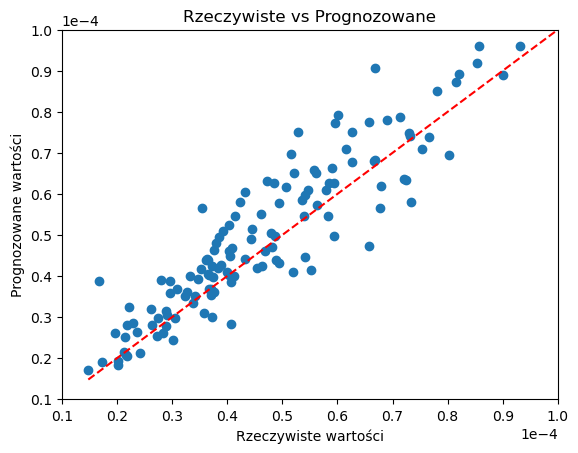

Porównanie prognozowanych wartości z rzeczywistymi dla modelu (alpha=10.0) regresji wielomianowej z regularyzacją metodą Ridge:
5.662271264167943e-05 3.54838137357843e-05
4.716026605590639e-05 4.803525779018137e-05
7.479829644837787e-05 7.30581835866058e-05
5.7281552512125104e-05 5.622779393819121e-05
4.3915067299256095e-05 4.884156896357712e-05
6.811851325402775e-05 6.656795998191929e-05
4.616610433831168e-05 4.684726889431436e-05
7.80111760335282e-05 6.897193155894331e-05
3.6804845478675124e-05 3.66577376312569e-05
4.2494855725355305e-05 3.723360706646763e-05


In [75]:
show_plot(y_test, y_pred)

print(f"Porównanie prognozowanych wartości z rzeczywistymi dla modelu (alpha={model.alpha_}) regresji wielomianowej z regularyzacją metodą Ridge:")
for i in range(10):
	print(y_pred[i], np.array(y_test)[i])

In [76]:
coef_summary = summarize_coefficients(model, selected_feature_names)  
print(coef_summary)

                                           Cecha  Współczynnik         Moduł
7                  GDP_growth Regulatory_quality  3.073226e-05  3.073226e-05
4                                           Year -7.274875e-06  7.274875e-06
0                       Previous_year_fatalities -5.210642e-06  5.210642e-06
6                             Regulatory_quality  3.748310e-06  3.748310e-06
30    Unemployment_rate Previous_year_fatalities -3.733160e-06  3.733160e-06
48  Political_stability Previous_year_fatalities -3.692367e-06  3.692367e-06
31                   Unemployment_rate Pop_15_64  3.102503e-06  3.102503e-06
23                        Govt_debt_GDP Pop_0_14  2.820830e-06  2.820830e-06
37                 Life_expectancy CO2_transport -2.770524e-06  2.770524e-06
5                                    Inflation^2 -2.625165e-06  2.625165e-06
45               Pop_density Political_stability  2.552239e-06  2.552239e-06
47                   Unemployment_rate Urban_pop -2.357176e-06  2.357176e-06

# Punkt odniesienia
Naszym punktem odniesienia było przewidywanie liczby ofiar w danym kraju na podstawie liczby ofiar z poprzedniego roku.

### Wyniki

``` txt
R^2 na zbiorze testowym: 0.9152568013766927
MSE na zbiorze testowym: 1.50296827959409e-10
MAE na zbiorze testowym: 8.202005676126758e-06
```

# Regresja wieloraka

## Model bez regularyzacji

### Wyniki

``` txt
R² dla zbioru testowego: 0.4979799522371732  
MSE: 2.5250488523734805e-10  
MAE: 1.0107486010106922e-05  
```

### 10 najbardziej znaczących cech

``` txt
                       Cecha  Współczynnik         Moduł  
                 Pop_65_plus  2.508084e-02  2.508084e-02  
                    Pop_0_14  2.007071e-02  2.007071e-02  
                   Pop_15_64  1.810967e-02  1.810967e-02  
    Previous_year_fatalities  3.703261e-05  3.703261e-05  
                  GDP_growth  3.673346e-06  3.673346e-06  
                        Year -3.309423e-06  3.309423e-06  
          Regulatory_quality -3.303263e-06  3.303263e-06  
             Life_expectancy -3.174506e-06  3.174506e-06  
                   Inflation -1.273544e-06  1.273544e-06  
              GNI_per_capita  8.933743e-07  8.933743e-07
```

## Regularyzacja metodą Lasso

### Wyniki dla regularyzacji L1 (alpha=5.565246446100539e-08)

``` txt
R² dla zbioru testowego: 0.4769286899430232
MSE: 2.6309320057131437e-10
MAE: 1.0304491196963346e-05
```

### 10 najbardziej znaczących cech

``` txt
                       Cecha  Współczynnik         Moduł
    Previous_year_fatalities  3.715946e-05  3.715946e-05
                  GDP_growth  3.650507e-06  3.650507e-06
          Regulatory_quality -2.954116e-06  2.954116e-06
                        Year -2.898442e-06  2.898442e-06
             Life_expectancy -2.287227e-06  2.287227e-06
                   Inflation -1.098664e-06  1.098664e-06
                 Pop_65_plus  7.665440e-07  7.665440e-07
               CO2_transport  5.888060e-07  5.888060e-07
         Political_stability  4.139171e-07  4.139171e-07
                   Urban_pop  4.029857e-07  4.029857e-07
```

## Regularyzacja metodą Ridge

### Wyniki dla regularyzacji z użyciem regresji grzbietowej (alpha=1.0)

``` txt
R² dla zbioru testowego: 0.49159156827439854
MSE: 2.5571809986206483e-10
MAE: 1.0202059252231973e-05
```

### 10 najbardziej znaczących cech

``` txt
                       Cecha  Współczynnik         Moduł
    Previous_year_fatalities  3.678163e-05  3.678163e-05
                  GDP_growth  3.685258e-06  3.685258e-06
                        Year -3.414225e-06  3.414225e-06
          Regulatory_quality -3.353722e-06  3.353722e-06
             Life_expectancy -3.176654e-06  3.176654e-06
                   Inflation -1.288661e-06  1.288661e-06
              GNI_per_capita  7.650751e-07  7.650751e-07
               Govt_debt_GDP  5.813411e-07  5.813411e-07
               CO2_transport  5.558847e-07  5.558847e-07
                 Pop_65_plus  5.492995e-07  5.492995e-07
```

## Regularyzacja metodą Ridge i Lasso

### Wyniki dla ElasticNeta (alpha=5.858154153790043e-08, l1_ratio=0.95)

``` txt
R² dla zbioru testowego: 0.47692868736072247
MSE: 2.63093201870154e-10
MAE: 1.0304491248962385e-05
```

### 10 najbardziej znaczących cech

``` txt
                       Cecha  Współczynnik         Moduł
    Previous_year_fatalities  3.715946e-05  3.715946e-05
                  GDP_growth  3.650507e-06  3.650507e-06
          Regulatory_quality -2.954116e-06  2.954116e-06
                        Year -2.898442e-06  2.898442e-06
             Life_expectancy -2.287227e-06  2.287227e-06
                   Inflation -1.098664e-06  1.098664e-06
                 Pop_65_plus  7.665441e-07  7.665441e-07
               CO2_transport  5.888061e-07  5.888061e-07
         Political_stability  4.139171e-07  4.139171e-07
                   Urban_pop  4.029856e-07  4.029856e-07
```

## Wnioski
Wszystkie modele osiągają gorsze wyniki niż punkt odniesienia. Prawdopodobnie modele liniowe nie są w stanie wychwycić zależności między danymi lub występuje przetrenowanie.  

Model bez regularyzacji osiąga najlepszy wynik. Drugi jest model z regularyzacją metodą Ridge, a ostanie jest Lasso i ElasticNet, które otrzymują podobne wyniki.  

We wszystkich regularyzowanych modelach najważniejsze są "Previous_year_fatalities", "GDP_growth", "Regulatory_quality" i  "Year". Natomiast model bez regularyzacji korzysta z cech opisujących rozkład społeczeństwa pod względem wieku i "Previous_year_fatalities".

# Regresja wielomianowa z wielomianową kombinacją cech

## Model bez regularyzacji

### Wyniki

``` txt
Wyniki dla wielomianu stopnia 2:
R² dla zbioru testowego: -0.4419506940620115
MSE: 7.252690328694938e-10
MAE: 1.83785917926238e-05

Wyniki dla wielomianu stopnia 3:
R² dla zbioru testowego: -15.262381067389416
MSE: 8.17961490463658e-09
MAE: 6.290168940953838e-05
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                            Cecha  Współczynnik        Moduł
             Pop_0_14 Pop_65_plus  -4445.805411  4445.805411
            Pop_15_64 Pop_65_plus  -4010.762210  4010.762210
               Pop_0_14 Pop_15_64  -3210.312296  3210.312296
                    Pop_65_plus^2  -2777.154768  2777.154768
                       Pop_0_14^2  -1779.265707  1779.265707
                      Pop_15_64^2  -1448.083994  1448.083994
     Population_total Pop_65_plus     -1.879046     1.879046
        Population_total Pop_0_14     -1.503744     1.503744
       Population_total Pop_15_64     -1.356822     1.356822
      Pop_65_plus Life_expectancy      1.191574     1.191574
```

## Regularyzacja metodą Lasso

### Wyniki dla regularyzacji L1

``` txt
Wyniki dla wielomianu stopnia 2 (alpha=6.306749198597784e-07):
R² dla zbioru testowego: 0.6269374424428065
MSE: 1.8764214437674087e-10
MAE: 8.404465682639329e-06

Wyniki dla wielomianu stopnia 3 (alpha=8.467288381077802e-07):
R² dla zbioru testowego: 0.32713098724069767
MSE: 3.384381034257495e-10
MAE: 1.1999667909835449e-05
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                                         Cecha  Współczynnik         Moduł
                      Previous_year_fatalities  3.714178e-05  3.714178e-05
                                    GDP_growth  2.198887e-06  2.198887e-06
                                          Year -1.703078e-06  1.703078e-06
                               Life_expectancy -1.495305e-06  1.495305e-06
                            Regulatory_quality -1.453229e-06  1.453229e-06
                    GDP_growth Life_expectancy -1.262508e-06  1.262508e-06
            Inflation Previous_year_fatalities -1.153163e-06  1.153163e-06
      Cars_per_capita Previous_year_fatalities -5.687856e-07  5.687856e-07
                 Year Previous_year_fatalities -4.976184e-07  4.976184e-07
                                        Year^2  3.570838e-07  3.570838e-07
```

## Regularyzacja metodą Ridge

### Wyniki dla regularyzacji L2

``` txt
Wyniki dla wielomianu stopnia 2 (alpha=10.0):
R² dla zbioru testowego: 0.5160561142984088
MSE: 2.4341297895363646e-10
MAE: 1.0119568986972238e-05

Wyniki dla wielomianu stopnia 3 (alpha=5.0):
R² dla zbioru testowego: -1.3303301425151721
MSE: 1.1721040779608826e-09
MAE: 2.4477829790763235e-05
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                                        Cecha  Współczynnik     Moduł
                     Previous_year_fatalities      0.000018  0.000018
                                         Year     -0.000010  0.000010
                              Life_expectancy     -0.000008  0.000008
                           Year CO2_transport     -0.000006  0.000006
                               GNI_per_capita     -0.000006  0.000006
                     Pop_0_14 Life_expectancy     -0.000004  0.000004
                            Unemployment_rate     -0.000003  0.000003
         Pop_65_plus Previous_year_fatalities      0.000003  0.000003
                                     Pop_0_14     -0.000003  0.000003
                Year Previous_year_fatalities     -0.000003  0.000003
```

## Regularyzacja metodą Ridge i Lasso

### Wyniki dla ElasticNeta

``` txt
Wyniki dla wielomianu stopnia 2 (alpha=1.261349839719557e-05, l1_ratio=0.05):
R² dla zbioru testowego: 0.626933309346345
MSE: 1.8764422323206213e-10
MAE: 8.40448679921187e-06

Wyniki dla wielomianu stopnia 3 (alpha=8.912935137976635e-07, l1_ratio=0.95):
R² dla zbioru testowego: 0.3271305723061526
MSE: 3.3843831212856954e-10
MAE: 1.1999672938370949e-05
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                                         Cecha  Współczynnik         Moduł
                      Previous_year_fatalities  3.713918e-05  3.713918e-05
                                    GDP_growth  2.198869e-06  2.198869e-06
                                          Year -1.704148e-06  1.704148e-06
                               Life_expectancy -1.496476e-06  1.496476e-06
                            Regulatory_quality -1.453964e-06  1.453964e-06
                    GDP_growth Life_expectancy -1.262324e-06  1.262324e-06
            Inflation Previous_year_fatalities -1.153054e-06  1.153054e-06
      Cars_per_capita Previous_year_fatalities -5.687232e-07  5.687232e-07
                 Year Previous_year_fatalities -4.986524e-07  4.986524e-07
                                        Year^2  3.566351e-07  3.566351e-07
```

## Wnioski

We wszystkich przypadkach stopień wielomianu równy 2 dawał lepsze wyniki niż 3. Prawdopodobnie wynika to z przetrenowania modelu w przypadku, gdy stopień wynosi 3.

Najlepsze wyniki daje model z regulryzacją metodą Lasso i ElasticNet. Drugi jest model z regularyzacją metodą Ridge, a ostatni model bez regularyzacji.

Metody z regularyzacją osiągają lepsze wyniki niż wtedy, gdy modele były liniowe. Oznacz to, że regularyzacja pomaga, gdy mamy dużo cech i łatwo jest przetrenować model.

Niestety modele dalej osiągają gorsze wyniki niż w punkcie odniesienia.  

Modele wykorzystują identyczne cechy i ich kombinacje, co w przypadku modeli liniowych.

# Zachłanny algorytm doboru cech dla regresja wielomianowej z wielomianową kombinacją cech (stopień wielomianu=2)

## Model bez regularyzacji

### Wyniki

``` txt
R^2 na zbiorze testowym: 0.8042462686595905
MSE na zbiorze testowym: 9.845976009755842e-11
MAE na zbiorze testowym: 7.05699424046031e-06
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                                        Cecha  Współczynnik        Moduł
54                       Pop_0_14 Pop_65_plus   5506.317598  5506.317598
59                                Pop_65_plus   4968.497841  4968.497841
53                        Pop_15_64 Land_area   3976.088057  3976.088057
62             Population_total CO2_transport   3440.332145  3440.332145
52           Regulatory_quality CO2_transport   2203.241739  2203.241739
58                                  Land_area   1793.865370  1793.865370
63  Population_total Previous_year_fatalities      0.110888     0.110888
55                                Pop_15_64^2      0.088741     0.088741
60                    Govt_debt_GDP Land_area      0.080070     0.080070
6               GDP_growth Regulatory_quality     -0.020020     0.020020
```

## Regularyzacja metodą Ridge

### Wyniki

``` txt
R^2 na zbiorze testowym: 0.7495376205286723
MSE na zbiorze testowym: 1.2597698969695142e-10
MAE na zbiorze testowym: 7.825195011632706e-06
```

### 10 najbardziej znaczących cech dla wielomianu stopnia 2

``` txt
                                           Cecha  Współczynnik         Moduł
                   GDP_growth Regulatory_quality  3.073226e-05  3.073226e-05
                                            Year -7.274875e-06  7.274875e-06
                        Previous_year_fatalities -5.210642e-06  5.210642e-06
                              Regulatory_quality  3.748310e-06  3.748310e-06
      Unemployment_rate Previous_year_fatalities -3.733160e-06  3.733160e-06
    Political_stability Previous_year_fatalities -3.692367e-06  3.692367e-06
                     Unemployment_rate Pop_15_64  3.102503e-06  3.102503e-06
                          Govt_debt_GDP Pop_0_14  2.820830e-06  2.820830e-06
                   Life_expectancy CO2_transport -2.770524e-06  2.770524e-06
                                     Inflation^2 -2.625165e-06  2.625165e-06
```

## Wnioski

Zachłanny algorytm doboru cech poprawił wyniki regresji i pozwolił na uzyskanie lepszych wyników niż punkt odniesienia.

Najlepszy wynik osiągnął model bez regularyzacji, a drugi był model z regularyzacją metodą Ridge.

Modele wykorzystaywały podobne cechy, co w poprzednich przypadkach. Ciekawym zjawiskiem jest fakt, iż model bez regularyzacji nie korzysta tak mocno z cechy "Previous_year_fatalities" jak z inne modele.  

# Weryfikacja hipotezy

## Hipoteza

Kraje bardziej zamożne i bardziej rozwinięte będą miały mniej ofiar śmiertelych w wypadkach drogowych per capita.

## Wnioski

Dla modeli bez regularyzacji najważniejszy był rozkład społeczeństwa względem wieku, natomiast dla modeli z regularyzacją wzrost PKB, rok, liczba ofiar z poprzedniego roku i jakość regulacji prawnych.

Możemy zaobserwować, że z roku na rok maleje liczba ofiar śmiertelnych. Widzizmy również, że w krajach rozwijających się (duży wzrost PKB rok do roku) występuje najwięcej ofiar śmiertelnych. Mniej występuje w krajach rozwiniętych (dłuższa oczekiwana długość życia i wyższa jakość regulacji prawnych). Co częściowo potwierdza naszą hipotezę, należałoby jednak przeprowadzić więcej badań z innymi cechami i hiperparametrami modeli, czego nie byliśmy w stanie zrobić z powodu ograniczeń czasowych i sprzętowych.
